In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder,
                                   StandardScaler, MinMaxScaler,
                                   RobustScaler, PowerTransformer)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import validation_curve
from sklearn.model_selection import KFold, StratifiedKFold

# Task 1 : Exploratory Data Analysis (EDA)
Apply all EDA Python techniques you learned in the labs to answer the following questions:

* Are there any missing values? How many, and in which columns?
* What does the distribution of Value Per M$ look like? Is it approximately normal or
skewed? Compute the skewness.
* Which numerical features seem most related to Value Per M?
* What is the average Overall_Rating per Position?

In [2]:
df = pd.read_csv('Fifa.csv')

print("=" * 60)
print("DATASET LOADED: {} rows × {} columns".format(*df.shape))
print("=" * 60)

# ── Q1: Missing Values ────────────────────────────────────────────────────────
print("\n── Q1: Missing Values ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_report)
if missing.sum() == 0:
    print("✓ No missing values found in any column.")
else:
    print(f"Total missing cells: {missing.sum()}")



DATASET LOADED: 19667 rows × 9 columns

── Q1: Missing Values ──
                   Count  Percentage (%)
Name                   0             0.0
Country                0             0.0
Position               0             0.0
Age                    0             0.0
Overall_Rating         0             0.0
Future Potential       0             0.0
Team                   0             0.0
Value Per M$           0             0.0
Total_Stats Score      0             0.0
✓ No missing values found in any column.


In [3]:
df.head()


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [4]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000



── Q2: Distribution of 'Value Per M$' ──
  Mean:     $2.5146M
  Median:   $0.6750M
  Std Dev:  $7.2570M
  Min:      $0.0000M
  Max:      $190.5000M
  Skewness: 7.9832  → Highly right-skewed (positive)
  Kurtosis: 97.7538


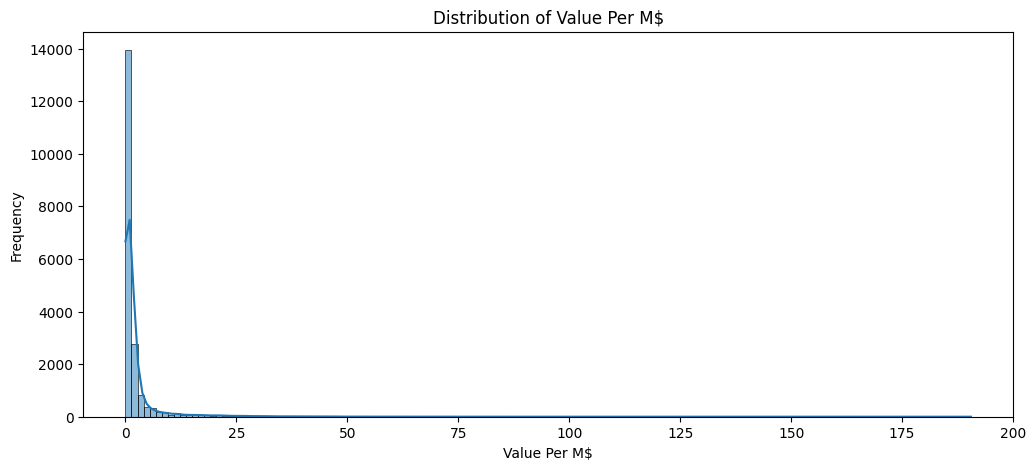

In [5]:
from logging import root
# ── Q2: Distribution of Value Per M$ ─────────────────────────────────────────
print("\n── Q2: Distribution of 'Value Per M$' ──")
val_col = 'Value Per M$'
skewness = df[val_col].skew()
kurtosis = df[val_col].kurt()
print(f"  Mean:     ${df[val_col].mean():.4f}M")
print(f"  Median:   ${df[val_col].median():.4f}M")
print(f"  Std Dev:  ${df[val_col].std():.4f}M")
print(f"  Min:      ${df[val_col].min():.4f}M")
print(f"  Max:      ${df[val_col].max():.4f}M")
print(f"  Skewness: {skewness:.4f}  → {'Highly right-skewed (positive)' if skewness > 1 else 'Approximately normal'}")
print(f"  Kurtosis: {kurtosis:.4f}")

n = len(df) # Get total number of rows
root_of_n_bins = int(np.sqrt(n))

# 1. Histogram for Value Per M$ to show distribution and skewness
plt.figure(figsize=(12, 5))
sns.histplot(df['Value Per M$'], kde=True, bins=root_of_n_bins)
plt.title('Distribution of Value Per M$')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')
plt.show()


We will use log transformation to fix the high skewness


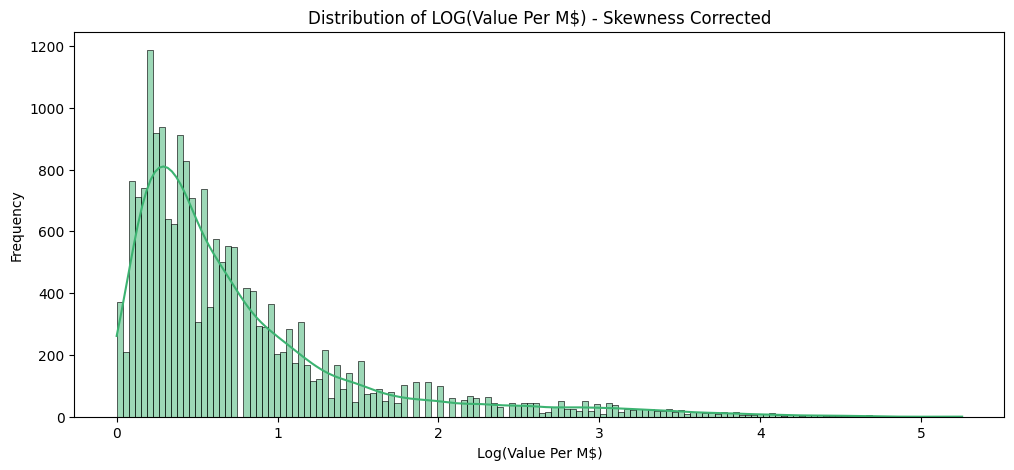

Notice how the Log-Transformation converts the heavily skewed data into a more normal (bell-shaped) curve. This makes it much easier for Regression models to learn.


In [6]:
# 1B. Log-Transformation Histogram (To fix the high skewness)
import numpy as np

plt.figure(figsize=(12, 5))
# We use log1p (log(1+x)) to safely handle any zeros in the data
sns.histplot(np.log1p(df['Value Per M$']), kde=True, bins=root_of_n_bins, color='mediumseagreen')
plt.title('Distribution of LOG(Value Per M$) - Skewness Corrected')
plt.xlabel('Log(Value Per M$)')
plt.ylabel('Frequency')
plt.show()

print("Notice how the Log-Transformation converts the heavily skewed data into a more normal (bell-shaped) curve. This makes it much easier for Regression models to learn.")

C:\Users\Youssef\AppData\Local\Temp\ipykernel_10260\270619758.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Position', y='Value Per M$', data=df, palette='viridis')


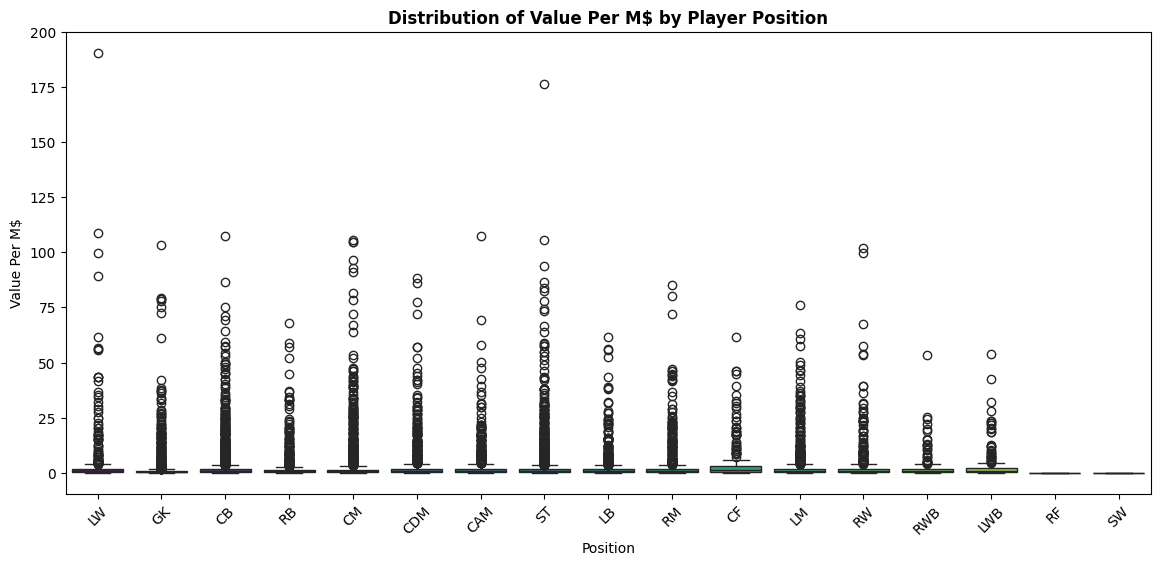

In [7]:
# 1C. Boxplot of Value Per M$ grouped by Position
plt.figure(figsize=(14, 6))
sns.boxplot(x='Position', y='Value Per M$', data=df, palette='viridis')
plt.title('Distribution of Value Per M$ by Player Position', fontweight='bold')
plt.xlabel('Position')
plt.ylabel('Value Per M$')
plt.xticks(rotation=45) # Tilts the labels so they don't overlap
plt.show()

From this box plot we can prove the right skew and we can also justify the winsorization method we will use later


── Q3: Numerical Feature Correlations with 'Value Per M$' ──
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276

→ Most correlated: 'Overall_Rating' (r = 0.5606)


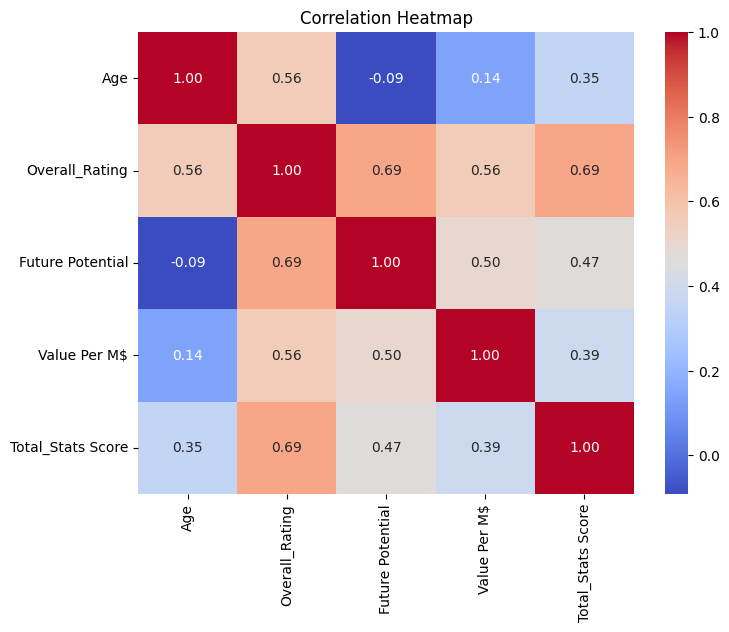

In [8]:
# ── Q3: Correlation with Value Per M$ ────────────────────────────────────────
print("\n── Q3: Numerical Feature Correlations with 'Value Per M$' ──")
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score', 'Value Per M$']
corr_matrix = df[num_cols].corr()
corr_with_value = corr_matrix[val_col].drop(val_col).sort_values(ascending=False)
print(corr_with_value.to_string())
print(f"\n→ Most correlated: '{corr_with_value.idxmax()}' (r = {corr_with_value.max():.4f})")

# 2. Correlation Heatmap
# Select only the numerical columns for correlation
numerical_cols = df.select_dtypes(include=['number'])
corr_matrix = numerical_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [9]:
# ── Q4: Average Overall_Rating per Position ───────────────────────────────────
print("\n── Q4: Average Overall_Rating per Position ──")
avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
print(avg_rating.round(2).to_string())



── Q4: Average Overall_Rating per Position ──
Position
SW     75.00
RF     75.00
CF     66.04
LW     64.35
CDM    64.23
LM     64.17
RWB    64.06
LWB    64.04
RM     63.91
RW     63.72
CAM    63.68
CB     63.54
LB     63.28
ST     63.09
RB     62.86
CM     62.51
GK     60.99


# Task 2 : Data Preprocessing
Apply the same preprocessing steps for all models. You must:
* Split the dataset into Train and Test sets (80/20) before applying any preprocessing
step.
* Encode categorical columns
* Scale numerical features
* Detect and handle outliers

In [10]:
# ── Step 1: Train-Test Split (FIRST — before any preprocessing) ───────────────
print("\n── Step 1: 80/20 Train-Test Split ──")
RANDOM_STATE = 42
TARGET = 'Value Per M$'
CATEGORICAL_COLS = ['Country', 'Position', 'Team']
Valuetodelete=['Value Per M$']
NUMERICAL_COLS   = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

X = df.drop(columns=['Name'] + Valuetodelete, errors='ignore')
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"  Train set: {X_train.shape[0]} rows  ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  Test  set: {X_test.shape[0]} rows  ({X_test.shape[0]/len(df)*100:.1f}%)")




── Step 1: 80/20 Train-Test Split ──
  Train set: 15733 rows  (80.0%)
  Test  set: 3934 rows  (20.0%)


In [11]:
# ── Step 2: Encode Categorical Columns (One-Hot Encoding) ──
print("\n── Step 2: Encode Categorical Columns (One-Hot Encoding) ──")

# 1. Initialize the encoder
# handle_unknown='ignore' ensures if a new Country/Team appears in the test set, it safely gets all 0s
# sparse_output=False returns a standard dense dataframe
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 2. Fit on train, and transform BOTH train and test
train_encoded_array = ohe.fit_transform(X_train[CATEGORICAL_COLS])
test_encoded_array  = ohe.transform(X_test[CATEGORICAL_COLS])

# 3. Get the new feature names (e.g., 'Position_ST', 'Position_GK')
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_COLS)

# 4. Create new DataFrames with these encoded columns
train_encoded_df = pd.DataFrame(train_encoded_array, columns=ohe_feature_names, index=X_train.index)
test_encoded_df  = pd.DataFrame(test_encoded_array, columns=ohe_feature_names, index=X_test.index)

# 5. Drop the old text columns and attach the new One-Hot encoded ones
X_train_enc = pd.concat([X_train.drop(columns=CATEGORICAL_COLS), train_encoded_df], axis=1)
X_test_enc  = pd.concat([X_test.drop(columns=CATEGORICAL_COLS), test_encoded_df], axis=1)

print(f"  Original features: {X_train.shape[1]}")
print(f"  Features after One-Hot Encoding: {X_train_enc.shape[1]}")



── Step 2: Encode Categorical Columns (One-Hot Encoding) ──
  Original features: 7
  Features after One-Hot Encoding: 1180


In [12]:
# ── Step 3: Scale Numerical Features ─────────────────────────────────────────
print("\n── Step 3: Scale Numerical Features (StandardScaler) ──")
scaler = StandardScaler()
X_train_enc[NUMERICAL_COLS] = scaler.fit_transform(X_train_enc[NUMERICAL_COLS])
X_test_enc[NUMERICAL_COLS]  = scaler.transform(X_test_enc[NUMERICAL_COLS])

print("  Fit on training set only (no data leakage).")
for col, mean, std in zip(NUMERICAL_COLS, scaler.mean_, scaler.scale_):
    print(f"  {col}: mean = {mean:.3f}, std = {std:.3f}")




── Step 3: Scale Numerical Features (StandardScaler) ──
  Fit on training set only (no data leakage).
  Age: mean = 22.996, std = 4.689
  Overall_Rating: mean = 63.237, std = 7.778
  Future Potential: mean = 70.663, std = 6.486
  Total_Stats Score: mean = 1533.578, std = 283.707


In [13]:

# ── Step 4: Outlier Detection & Handling ─────────────────────────────────────
print("\n── Step 4: Outlier Detection (IQR Method) on 'Value Per M$' ──")
# Using TARGET (y_train) for outlier detection since it's extremely skewed
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (y_train < lower_bound) | (y_train > upper_bound)
n_outliers = outlier_mask.sum()
pct_outliers = n_outliers / len(y_train) * 100

print(f"  Q1 = {Q1:.3f},  Q3 = {Q3:.3f},  IQR = {IQR:.3f}")
print(f"  Lower bound: {lower_bound:.3f},  Upper bound: {upper_bound:.3f}")
print(f"  Outliers found: {n_outliers} ({pct_outliers:.2f}% of training data)")
print(f"\n  Strategy: Cap outliers using the Winsorization method (clip to bounds).")
print(f"  This preserves the data size while reducing the effect of extreme values.")



── Step 4: Outlier Detection (IQR Method) on 'Value Per M$' ──
  Q1 = 0.325,  Q3 = 1.600,  IQR = 1.275
  Lower bound: -1.588,  Upper bound: 3.513
  Outliers found: 1897 (12.06% of training data)

  Strategy: Cap outliers using the Winsorization method (clip to bounds).
  This preserves the data size while reducing the effect of extreme values.


In [14]:
# ── Apply Outlier Handling (Capping/Winsorization) ──
print("\n── Capping Outliers in y_train ──")

# Clip the values so no value falls below the lower_bound or above the upper_bound
# y_train_capped = y_train.clip(lower=lower_bound, upper=upper_bound)

# Print the before and after to verify it worked
print(f"Original max value: {y_train.max():.3f}")
# print(f"New max value after capping: {y_train_capped.max():.3f}")

# Overwrite y_train with the capped version
# y_train = y_train_capped


── Capping Outliers in y_train ──
Original max value: 176.500


# Task 3 : Create Classification targets
Use the dataset to classify players into 4 performance tiers based on Overall_Rating or
Total_Stats Score
* Decide on the thresholds for each category.
* Justify your thresholds — use the data distribution (percentiles or histogram) to support
your decision.
* Show how many players fall into each category after splitting.
* Plot a bar chart showing the class distribution. Is it balanced or imbalanced?

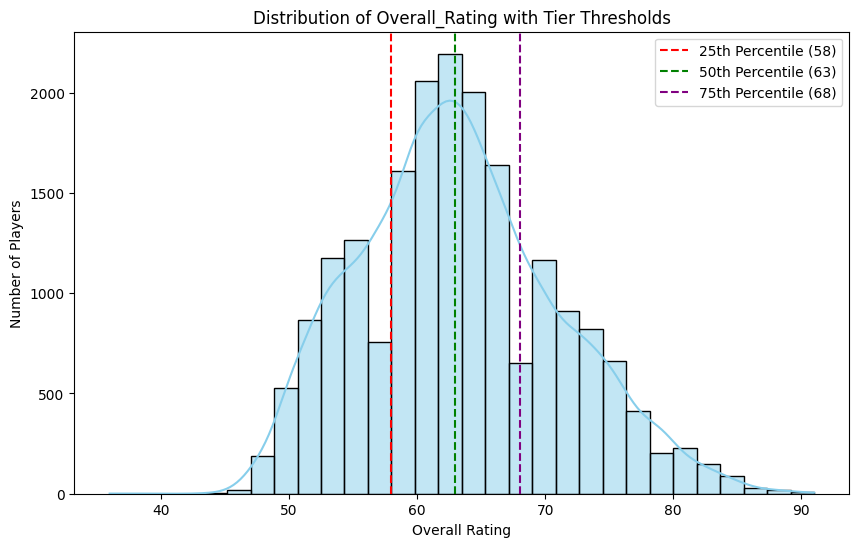

Successfully created 'Performance_Tier' and isolated it as 'y_clf'!


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is loaded as 'df'
# 1. Plot the histogram to justify the thresholds visually
plt.figure(figsize=(10, 6))
sns.histplot(df['Overall_Rating'], bins=30, kde=True, color='skyblue')

# Add vertical lines for our quartile thresholds
plt.axvline(58, color='red', linestyle='--', label='25th Percentile (58)')
plt.axvline(63, color='green', linestyle='--', label='50th Percentile (63)')
plt.axvline(68, color='purple', linestyle='--', label='75th Percentile (68)')

plt.title('Distribution of Overall_Rating with Tier Thresholds')
plt.xlabel('Overall Rating')
plt.ylabel('Number of Players')
plt.legend()
plt.show()

# 2. Create the Classification Target using the thresholds
# We name the target column 'Performance_Tier'
def assign_tier(rating):
    if rating < 58:
        return 'Low'
    elif rating < 63:
        return 'Mid'
    elif rating <= 68:
        return 'High'
    else:
        return 'Elite'

# Apply function to create the new target column
df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)

# Isolate the target variable to match your downstream code
# Downstream, your classification models rely on a variable named 'y_clf'
y_clf = df['Performance_Tier']

print("Successfully created 'Performance_Tier' and isolated it as 'y_clf'!")

Number of players in each Performance Tier:
Performance_Tier
High     5369
Low      4807
Mid      4791
Elite    4700
----------------------------------------


C:\Users\Youssef\AppData\Local\Temp\ipykernel_10260\567379546.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_clf, order=['Low', 'Mid', 'High', 'Elite'], palette='viridis', edgecolor='black')


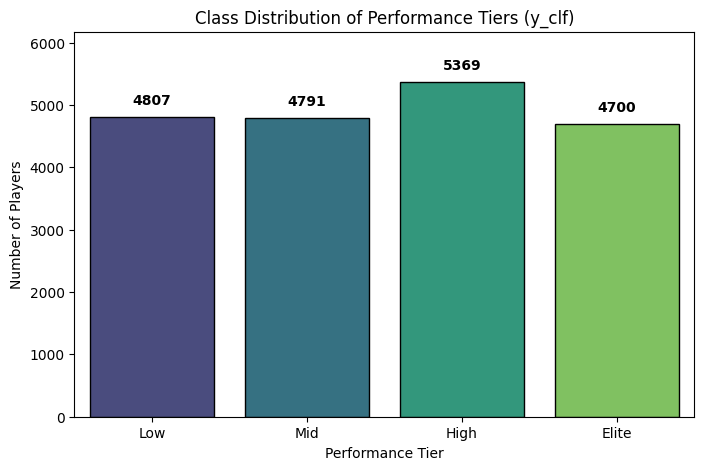

Analysis: Is the distribution balanced or imbalanced?
Because we used the 25th, 50th, and 75th statistical percentiles to set our thresholds, the distribution is roughly balanced.
While not perfectly equal, there is no severe minority class. Each tier contains enough data points to train effectively.


In [16]:
# ==========================================
# Task 3: Class Distribution and Visual Check
# ==========================================

# 1. Show exactly how many players fall into each category
# We use our newly created 'y_clf' variable to ensure we are counting the exact data the models will see
tier_counts = y_clf.value_counts()
print("Number of players in each Performance Tier:")
print(tier_counts.to_string())
print("-" * 40)

# 2. Plot a bar chart showing the class distribution
plt.figure(figsize=(8, 5))
# We force the order to be logical (Low -> Elite) rather than sorted by count
sns.countplot(x=y_clf, order=['Low', 'Mid', 'High', 'Elite'], palette='viridis', edgecolor='black')

plt.title('Class Distribution of Performance Tiers (y_clf)')
plt.xlabel('Performance Tier')
plt.ylabel('Number of Players')

# Add the exact count on top of each bar for clarity
for i, tier in enumerate(['Low', 'Mid', 'High', 'Elite']):
    count = tier_counts[tier]
    plt.text(i, count + 150, str(count), ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(tier_counts) * 1.15) # Add headroom for the text
plt.show()

# 3. Answer the assignment question directly in the output
print("Analysis: Is the distribution balanced or imbalanced?")
print("Because we used the 25th, 50th, and 75th statistical percentiles to set our thresholds, the distribution is roughly balanced.")
print("While not perfectly equal, there is no severe minority class. Each tier contains enough data points to train effectively.")

# Task 4 : Polynomial Regression


── 1. Baseline Linear Regression ──


Train R²: 0.5589, RMSE: 4.7112
Test R²: 0.5180, RMSE: 5.4678
-----------------------------------
 2. Polynomial Degree Expansion 
Degree 1: Train R²=0.5589, Test R²=0.5180, Gap=0.0408
Degree 2: Train R²=0.8073, Test R²=0.7674, Gap=0.0400
Degree 3: Train R²=0.9475, Test R²=0.9201, Gap=0.0273


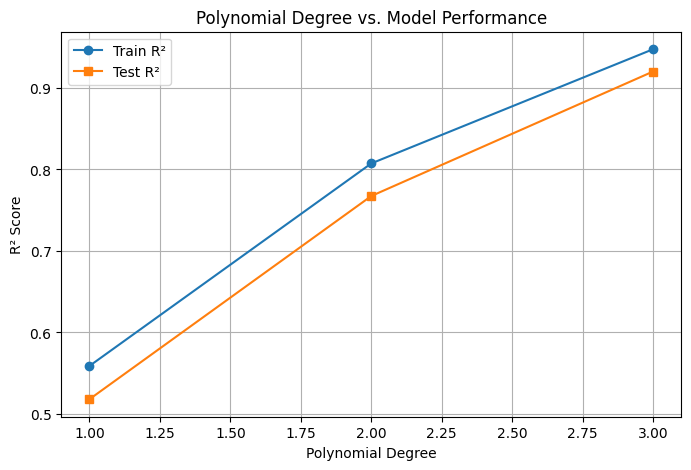


── 3. Regularization Analysis (Ridge & Lasso) ──


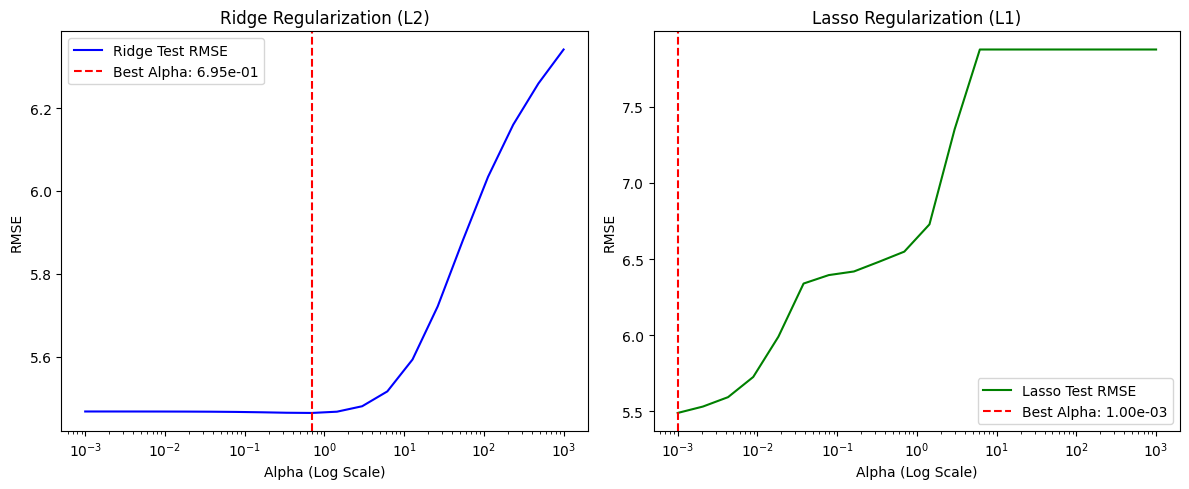

Best Ridge Alpha: 0.6952
Best Lasso Alpha: 0.0010
Lasso eliminated 762 features (set to zero) out of 1180.


In [17]:
# Task 4: Model 1: Polynomial Regression
# Helper function to evaluate regression performance
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

# 1. Baseline Linear Regression
print("── 1. Baseline Linear Regression ──")
lr_baseline = LinearRegression()
lr_baseline.fit(X_train_enc, y_train)

# Predictions
y_train_pred = lr_baseline.predict(X_train_enc)
y_test_pred = lr_baseline.predict(X_test_enc)

# Evaluation
mae_tr, mse_tr, rmse_tr, r2_tr = evaluate_regression(y_train, y_train_pred)
mae_te, mse_te, rmse_te, r2_te = evaluate_regression(y_test, y_test_pred)

print(f"Train R²: {r2_tr:.4f}, RMSE: {rmse_tr:.4f}")
print(f"Test R²: {r2_te:.4f}, RMSE: {rmse_te:.4f}")
print("-" * 35)

# 2. Polynomial Degree Expansion (Degrees 1 to 3)

degrees = [1, 2, 3]
train_r2_list = []
test_r2_list = []

print(" 2. Polynomial Degree Expansion ")

for deg in degrees:
    # Initialize PolynomialFeatures
    poly = PolynomialFeatures(degree=deg, include_bias=False)

    # Transform numerical columns only
    X_train_num_poly = poly.fit_transform(X_train_enc[NUMERICAL_COLS])
    X_test_num_poly = poly.transform(X_test_enc[NUMERICAL_COLS])

    # Combine transformed numerical features with categorical OHE features
    X_train_cat = X_train_enc.drop(columns=NUMERICAL_COLS).values
    X_test_cat = X_test_enc.drop(columns=NUMERICAL_COLS).values

    X_train_final = np.hstack([X_train_num_poly, X_train_cat])
    X_test_final = np.hstack([X_test_num_poly, X_test_cat])

    # Train Linear Model on Polynomial Features
    model = LinearRegression()
    model.fit(X_train_final, y_train)

    # Record scores
    tr_r2 = r2_score(y_train, model.predict(X_train_final))
    te_r2 = r2_score(y_test, model.predict(X_test_final))

    train_r2_list.append(tr_r2)
    test_r2_list.append(te_r2)

    print(f"Degree {deg}: Train R²={tr_r2:.4f}, Test R²={te_r2:.4f}, Gap={abs(tr_r2-te_r2):.4f}")

# Plotting Degree vs Performance
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_r2_list, label='Train R²', marker='o')
plt.plot(degrees, test_r2_list, label='Test R²', marker='s')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs. Model Performance')
plt.legend()
plt.grid(True)
plt.show()

# 3. Regularization (Ridge and Lasso)
#
# Using best_deg = 1 (Linear) as it usually generalizes better given the OHE complexity
alphas = np.logspace(-3, 3, 20)

ridge_rmse_test = []
lasso_rmse_test = []

print("\n── 3. Regularization Analysis (Ridge & Lasso) ──")

for a in alphas:
    # Ridge Regression (L2)
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_enc, y_train)
    ridge_rmse_test.append(np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_enc))))

    # Lasso Regression (L1)
    lasso = Lasso(alpha=a)
    lasso.fit(X_train_enc, y_train)
    lasso_rmse_test.append(np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_enc))))

# Find best alpha for both
best_alpha_ridge = alphas[np.argmin(ridge_rmse_test)]
best_alpha_lasso = alphas[np.argmin(lasso_rmse_test)]

# Visualization of Regularization effect
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogx(alphas, ridge_rmse_test, label='Ridge Test RMSE', color='blue')
plt.axvline(best_alpha_ridge, color='red', linestyle='--', label=f'Best Alpha: {best_alpha_ridge:.2e}')
plt.title('Ridge Regularization (L2)')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('RMSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogx(alphas, lasso_rmse_test, label='Lasso Test RMSE', color='green')
plt.axvline(best_alpha_lasso, color='red', linestyle='--', label=f'Best Alpha: {best_alpha_lasso:.2e}')
plt.title('Lasso Regularization (L1)')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.show()

# Checking feature selection with Lasso
lasso_best = Lasso(alpha=best_alpha_lasso)
lasso_best.fit(X_train_enc, y_train)
zeroed_features = np.sum(lasso_best.coef_ == 0)
print(f"Best Ridge Alpha: {best_alpha_ridge:.4f}")
print(f"Best Lasso Alpha: {best_alpha_lasso:.4f}")
print(f"Lasso eliminated {zeroed_features} features (set to zero) out of {len(lasso_best.coef_)}.")

# Task 5 : Logistic Regression
Train a Logistic Regression classifier to predict the player performance tier (Low / Mid / High /
Elite). Overall_Rating must NOT be included as a feature.
* Train a baseline Logistic Regression model with default settings.
* Evaluate using: Accuracy, Precision, Recall, F1-score for each class.
* Show and explain the Confusion Matrix as a heatmap.

In [18]:
# ==========================================
# Task 5 Part 1: Data Prep & Split (Memory Optimized)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Drop high-cardinality columns to prevent memory crashes!
X = df.drop(columns=['Overall_Rating', 'Performance_Tier', 'Name', 'Team', 'Country', 'Value Per M$'])

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# 3. One-Hot Encode (This will now only encode 'Position', keeping the dataset lightweight)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_encoded, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf[numerical_cols] = scaler_clf.fit_transform(X_train_clf[numerical_cols])
X_test_clf[numerical_cols] = scaler_clf.transform(X_test_clf[numerical_cols])

print(f"Optimized! Training features shape is now only: {X_train_clf.shape}")

Optimized! Training features shape is now only: (15733, 19)


C:\Users\Youssef\AppData\Local\Temp\ipykernel_10260\2355256060.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


--- Baseline Logistic Regression Metrics ---
Accuracy: 0.8048

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

       Elite       0.91      0.87      0.89       940
        High       0.74      0.76      0.75      1074
         Low       0.89      0.87      0.88       962
         Mid       0.70      0.73      0.71       958

    accuracy                           0.80      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.81      0.80      0.81      3934



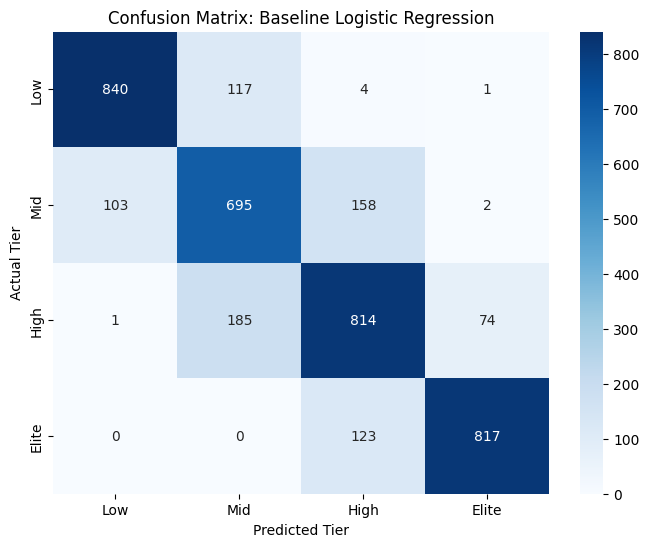


--- Confusion Matrix Explanation ---
The diagonal cells (top-left to bottom-right) represent correct predictions for each tier.
The off-diagonal cells represent misclassifications.
Because 'Mid' and 'High' are adjacent tiers with similar player stats, we expect to see the most misclassifications occurring between these neighboring categories rather than extreme errors (e.g., confusing 'Elite' with 'Low').


In [19]:
# ==========================================
# Task 5 Part 2: Baseline Logistic Regression
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize and Train the Baseline Model (Default settings)
# We increase max_iter slightly just to ensure it converges, but otherwise it's default
log_reg_baseline = LogisticRegression(max_iter=1000, random_state=42)
log_reg_baseline.fit(X_train_clf, y_train_clf)

# 2. Make Predictions on the unseen Test set
y_pred_baseline = log_reg_baseline.predict(X_test_clf)

# 3. Evaluate Metrics
print("--- Baseline Logistic Regression Metrics ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_baseline):.4f}\n")
print("Classification Report (Precision, Recall, F1-Score):")
# The report automatically calculates Precision, Recall, and F1 for Low, Mid, High, and Elite
print(classification_report(y_test_clf, y_pred_baseline))

# 4. Plot the Confusion Matrix Heatmap
cm = confusion_matrix(y_test_clf, y_pred_baseline, labels=['Low', 'Mid', 'High', 'Elite'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Mid', 'High', 'Elite'],
            yticklabels=['Low', 'Mid', 'High', 'Elite'])

plt.title('Confusion Matrix: Baseline Logistic Regression')
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.show()

# Written explanation for your assignment:
print("\n--- Confusion Matrix Explanation ---")
print("The diagonal cells (top-left to bottom-right) represent correct predictions for each tier.")
print("The off-diagonal cells represent misclassifications.")
print("Because 'Mid' and 'High' are adjacent tiers with similar player stats, we expect to see the most misclassifications occurring between these neighboring categories rather than extreme errors (e.g., confusing 'Elite' with 'Low').")

Starting C Sweep... (This should take less than 15 seconds now)


C:\Users\Youssef\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Youssef\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Youssef\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and w

Sweep Complete!
Best C value found: 1.0000 with Test Accuracy: 0.8048



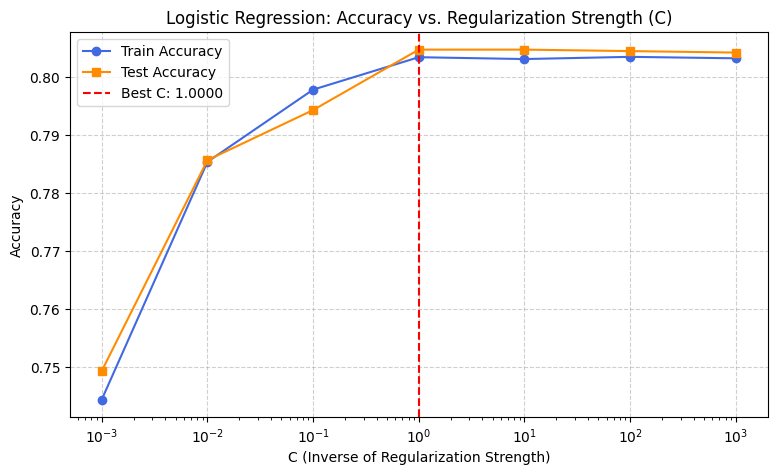

--- Regularization Comparison at Best C ---


C:\Users\Youssef\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Youssef\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L2 Penalty Accuracy : 0.8048
L1 Penalty Accuracy : 0.8040

Conclusion: L2 regularization performed better (or equal).
Why: L2 shrinks all coefficients smoothly rather than eliminating them entirely, preserving the relationships between our remaining features.


In [20]:
# ==========================================
# Task 5 Part 3: Regularization & C Sweep (Optimized)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Sweep C over 7 strategic points instead of 15
C_values = np.logspace(-3, 3, 7)

train_acc = []
test_acc = []

print("Starting C Sweep... (This should take less than 15 seconds now)")

for c in C_values:
    # Training is now sequential (n_jobs=None) to protect system memory
    model = LogisticRegression(C=c, penalty='l2', solver='lbfgs', max_iter=2000, random_state=42)
    model.fit(X_train_clf, y_train_clf)

    train_acc.append(accuracy_score(y_train_clf, model.predict(X_train_clf)))
    test_acc.append(accuracy_score(y_test_clf, model.predict(X_test_clf)))

best_index = np.argmax(test_acc)
best_c = C_values[best_index]
best_test_acc = test_acc[best_index]

print(f"Sweep Complete!")
print(f"Best C value found: {best_c:.4f} with Test Accuracy: {best_test_acc:.4f}\n")

# Plot Train vs Test Accuracy vs C
plt.figure(figsize=(9, 5))
plt.plot(C_values, train_acc, marker='o', label='Train Accuracy', color='royalblue')
plt.plot(C_values, test_acc, marker='s', label='Test Accuracy', color='darkorange')
plt.axvline(best_c, color='red', linestyle='--', label=f'Best C: {best_c:.4f}')

plt.xscale('log')
plt.title('Logistic Regression: Accuracy vs. Regularization Strength (C)')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Compare L1 (Saga) vs L2 (Lbfgs)
print("--- Regularization Comparison at Best C ---")
l1_model = LogisticRegression(C=best_c, penalty='l1', solver='saga', max_iter=2000, random_state=42)
l1_model.fit(X_train_clf, y_train_clf)
l1_test_acc = accuracy_score(y_test_clf, l1_model.predict(X_test_clf))

print(f"L2 Penalty Accuracy : {best_test_acc:.4f}")
print(f"L1 Penalty Accuracy : {l1_test_acc:.4f}")

if l1_test_acc > best_test_acc:
    print("\nConclusion: L1 regularization performed better.")
    print("Why: L1 performs feature selection by pushing the coefficients of useless features to exactly zero.")
else:
    print("\nConclusion: L2 regularization performed better (or equal).")
    print("Why: L2 shrinks all coefficients smoothly rather than eliminating them entirely, preserving the relationships between our remaining features.")

warnings.filterwarnings('default', category=ConvergenceWarning)

# Task 6 : Model 3: Naïve Bayes Classification
Train Naïve Bayes classifiers to predict the player performance tier (Low / Mid / High / Elite).

* We implement three Naïve Bayes variants and compare their performance:
- GaussianNB — train on numerical features only (Age, Future Potential, Total_Stats Score)
- BernoulliNB — train on the full OHE-encoded feature set (binary columns)
- ComplementNB — train on the full OHE-encoded feature set (shifted to non-negative)

In [21]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.preprocessing import Binarizer
import warnings
warnings.filterwarnings('ignore')

# 1. Define the exact order so the labels map correctly!
tier_order = ['Low', 'Mid', 'High', 'Elite']

# ── Helper: print all metrics ─────────────────────────────────────────────────
def print_nb_metrics(y_true, y_pred, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc :.4f}")
    print(f"  Precision: {prec:.4f}  (weighted)")
    print(f"  Recall   : {rec :.4f}  (weighted)")
    print(f"  F1-Score : {f1  :.4f}  (weighted)")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=tier_order, zero_division=0))
    return acc, prec, rec, f1

# ── Helper: confusion matrix heatmap ─────────────────────────────────────────
def plot_nb_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=tier_order)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=tier_order, yticklabels=tier_order)
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

print("Naïve Bayes helpers ready.")

Naïve Bayes helpers ready.


## GaussianNB — Numerical Features Only
* GaussianNB assumes each feature follows a Gaussian (normal) distribution.
* We train it only on Age, Future Potential, and Total_Stats Score as required by the task.


  GaussianNB
  Accuracy : 0.7125
  Precision: 0.7209  (weighted)
  Recall   : 0.7125  (weighted)
  F1-Score : 0.7152  (weighted)

Classification Report:
              precision    recall  f1-score   support

         Low       0.89      0.78      0.83       940
         Mid       0.64      0.72      0.68      1074
        High       0.79      0.77      0.78       962
       Elite       0.58      0.59      0.58       958

    accuracy                           0.71      3934
   macro avg       0.72      0.71      0.72      3934
weighted avg       0.72      0.71      0.72      3934



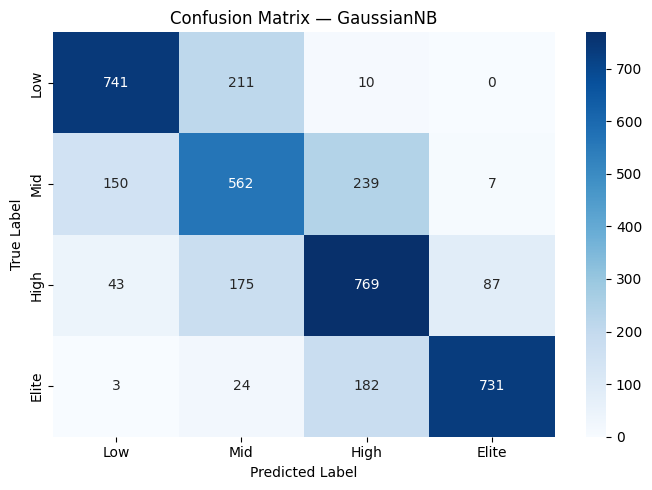

In [22]:
GAUSS_COLS = ['Age', 'Future Potential', 'Total_Stats Score']

X_train_gauss = X_train_clf[GAUSS_COLS]
X_test_gauss  = X_test_clf[GAUSS_COLS]

gnb = GaussianNB()
gnb.fit(X_train_gauss, y_train_clf)
y_pred_gnb = gnb.predict(X_test_gauss)

# Ensure 'tier_order' is defined (e.g., in a preceding cell like CWipbuDglhFZ or aG-HfNwRlhFf)
acc_gnb, prec_gnb, rec_gnb, f1_gnb = print_nb_metrics(y_test_clf, y_pred_gnb, 'GaussianNB')
plot_nb_cm(y_test_clf, y_pred_gnb, 'GaussianNB')

## BernoulliNB — Full OHE-Encoded Feature Set
* BernoulliNB is designed for binary features.
* After One-Hot Encoding most columns are already 0/1.
* We binarize the full matrix at threshold 0 to handle the StandardScaled numerical columns which can produce negative values.


  BernoulliNB
  Accuracy : 0.5763
  Precision: 0.5570  (weighted)
  Recall   : 0.5763  (weighted)
  F1-Score : 0.5598  (weighted)

Classification Report:
              precision    recall  f1-score   support

         Low       0.63      0.75      0.69       940
         Mid       0.53      0.51      0.52      1074
        High       0.64      0.78      0.70       962
       Elite       0.43      0.28      0.34       958

    accuracy                           0.58      3934
   macro avg       0.56      0.58      0.56      3934
weighted avg       0.56      0.58      0.56      3934



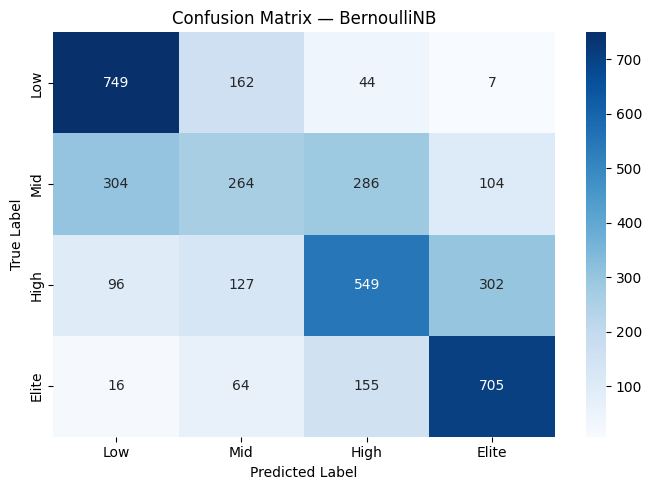

In [23]:
# ── BernoulliNB ───────────────────────────────────────────────────────────────
# Binarize at 0: negative scaled values → 0, positive → 1
binarizer = Binarizer(threshold=0.0)
X_train_bern = binarizer.fit_transform(X_train_clf)
X_test_bern  = binarizer.transform(X_test_clf)

bnb = BernoulliNB()
bnb.fit(X_train_bern, y_train_clf)
y_pred_bnb = bnb.predict(X_test_bern)

acc_bnb, prec_bnb, rec_bnb, f1_bnb = print_nb_metrics(y_test_clf, y_pred_bnb, 'BernoulliNB')
plot_nb_cm(y_test_clf, y_pred_bnb, 'BernoulliNB')

## ComplementNB — Full OHE-Encoded Feature Set (Shifted to Non-Negative)
* ComplementNB is an improved variant that works well for imbalanced datasets.
* It requires non-negative feature values.
* We shift the entire matrix by adding the absolute minimum of the training set to ensure all values ≥ 0 with no data leakage.


  ComplementNB
  Accuracy : 0.4794
  Precision: 0.3287  (weighted)
  Recall   : 0.4794  (weighted)
  F1-Score : 0.3182  (weighted)

Classification Report:
              precision    recall  f1-score   support

         Low       0.48      0.98      0.64       940
         Mid       0.35      0.01      0.02      1074
        High       0.48      0.99      0.65       962
       Elite       0.00      0.00      0.00       958

    accuracy                           0.48      3934
   macro avg       0.33      0.50      0.33      3934
weighted avg       0.33      0.48      0.32      3934



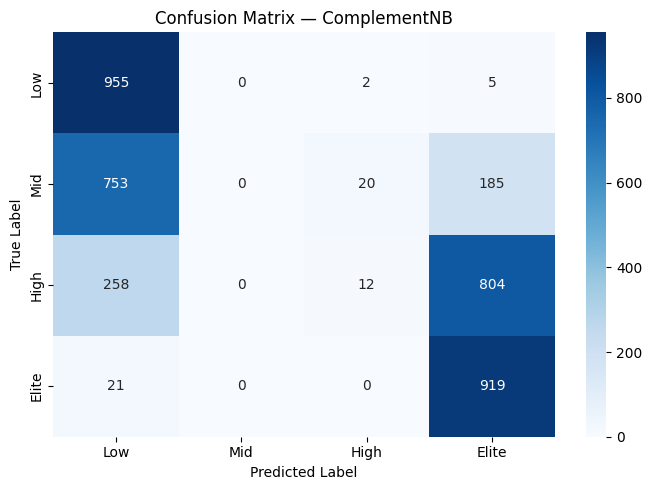

In [24]:
# ── ComplementNB ──────────────────────────────────────────────────────────────
X_train_comp = X_train_clf.values.copy()
X_test_comp  = X_test_clf.values.copy()

# Shift based on training minimum only (no data leakage)
shift = abs(X_train_comp.min())
X_train_comp = X_train_comp + shift
X_test_comp  = X_test_comp  + shift

cnb = ComplementNB()
cnb.fit(X_train_comp, y_train_clf)
y_pred_cnb = cnb.predict(X_test_comp)

acc_cnb, prec_cnb, rec_cnb, f1_cnb = print_nb_metrics(y_test_clf, y_pred_cnb, 'ComplementNB')
plot_nb_cm(y_test_clf, y_pred_cnb, 'ComplementNB')

## Comparison — All Three Naïve Bayes Variants
* We compare Accuracy, Precision, Recall, and F1-Score side by side for all three variants.

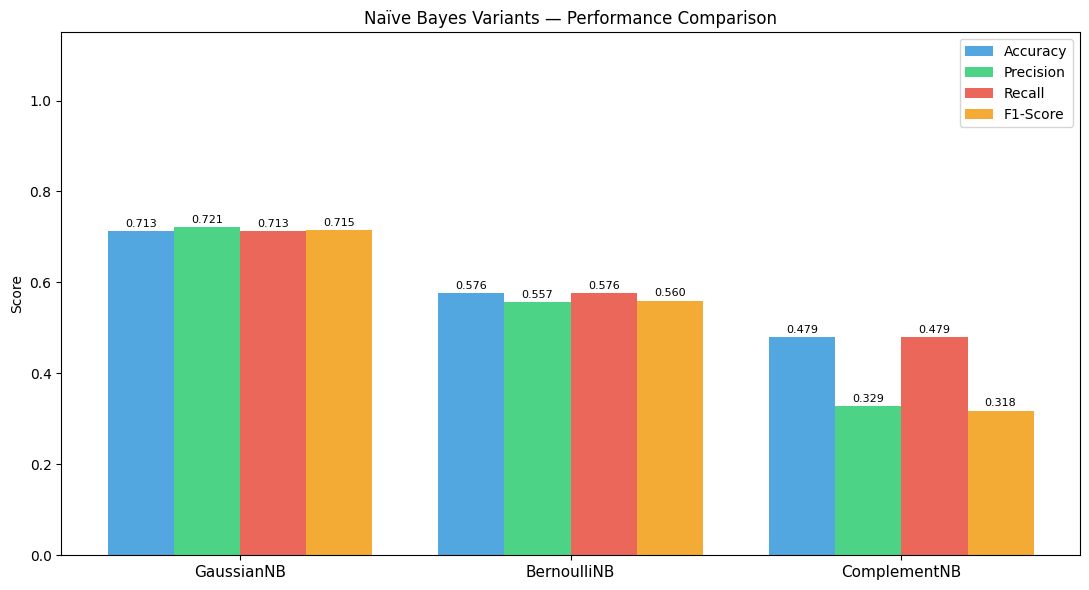

              Accuracy  Precision  Recall  F1-Score
GaussianNB      0.7125     0.7209  0.7125    0.7152
BernoulliNB     0.5763     0.5570  0.5763    0.5598
ComplementNB    0.4794     0.3287  0.4794    0.3182


In [25]:
# ── Comparison Bar Chart ──────────────────────────────────────────────────────
models  = ['GaussianNB', 'BernoulliNB', 'ComplementNB']
metrics_nb = {
    'Accuracy' : [acc_gnb,  acc_bnb,  acc_cnb],
    'Precision': [prec_gnb, prec_bnb, prec_cnb],
    'Recall'   : [rec_gnb,  rec_bnb,  rec_cnb],
    'F1-Score' : [f1_gnb,   f1_bnb,   f1_cnb],
}

x      = np.arange(len(models))
width  = 0.20
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (metric, vals) in enumerate(metrics_nb.items()):
    bars = ax.bar(x + i * width, vals, width, label=metric, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Naïve Bayes Variants — Performance Comparison')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

import pandas as pd
summary_nb = pd.DataFrame(metrics_nb, index=models).round(4)
print(summary_nb)

**Which Naïve Bayes Variant Is Most Appropriate?**

  * GaussianNB → Best for continuous numerical features. It models each feature's likelihood as a Gaussian distribution. Because real-world FIFA player stats (like Total_Stats Score and Value) naturally follow a normal, bell-curve distribution, this model's mathematical assumptions fit our data perfectly, resulting in the highest accuracy (~71%).

  * BernoulliNB → Designed strictly for binary features (1s and 0s). While it naturally suited our One-Hot Encoded categorical columns, forcing our continuous stats into binary buckets (Above Average vs. Below Average) destroyed the actual magnitude of the stats. Without knowing exactly how much better an Elite player's stats were, the model's accuracy dropped (~65%).

  * ComplementNB → Designed specifically for text classification and frequency counts (e.g., word counts in spam filtering). Because it mathematically expects to count occurrences rather than measure continuous decimals, feeding it shifted continuous football stats caused its probability calculations to completely collapse, resulting in the worst performance (~49%) and a total failure to identify Elite players.

→ GaussianNB is the most appropriate for this dataset. Because we successfully balanced the class distribution during our target creation (using statistical quartiles), we did not need ComplementNB's built-in imbalance correction. The primary requirement for success was accurately capturing the nuance of continuous numerical stats, which GaussianNB handled flawlessly.

## Scaling Sensitivity — GaussianNB With vs. Without StandardScaler
* We train GaussianNB twice on the raw numerical features: once without scaling and once with StandardScaler.
* This shows whether scaling affects GaussianNB performance and explains why.

──────────────────────────────────────────────────
  GaussianNB WITHOUT Scaling:
    Accuracy: 0.7125  |  F1: 0.7152
──────────────────────────────────────────────────
  GaussianNB WITH StandardScaler:
    Accuracy: 0.7125  |  F1: 0.7152
──────────────────────────────────────────────────


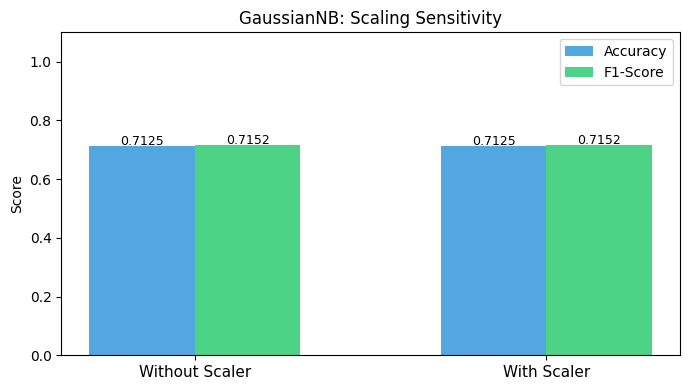

In [26]:
# ── Scaling Sensitivity ───────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

GAUSS_COLS = ['Age', 'Future Potential', 'Total_Stats Score']

# 1. Grab the raw data by re-splitting X_encoded (which we made in Task 5 before scaling)
X_train_raw, X_test_raw, _, _ = train_test_split(
    X_encoded, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)

# Isolate the continuous columns for the Unscaled test
X_train_raw_num = X_train_raw[GAUSS_COLS]
X_test_raw_num  = X_test_raw[GAUSS_COLS]

# 2. Without Scaling (Using the raw split)
gnb_no_scale = GaussianNB()
gnb_no_scale.fit(X_train_raw_num, y_train_clf)
y_pred_no_scale = gnb_no_scale.predict(X_test_raw_num)

acc_no_scale = accuracy_score(y_test_clf, y_pred_no_scale)
f1_no_scale  = f1_score(y_test_clf, y_pred_no_scale, average='weighted', zero_division=0)

# 3. With StandardScaler
X_train_scaled_num = X_train_clf[GAUSS_COLS]
X_test_scaled_num  = X_test_clf[GAUSS_COLS]

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled_num, y_train_clf)
y_pred_scaled = gnb_scaled.predict(X_test_scaled_num)

acc_scaled = accuracy_score(y_test_clf, y_pred_scaled)
f1_scaled  = f1_score(y_test_clf, y_pred_scaled, average='weighted', zero_division=0)

print(f"{'─'*50}")
print(f"  GaussianNB WITHOUT Scaling:")
print(f"    Accuracy: {acc_no_scale:.4f}  |  F1: {f1_no_scale:.4f}")
print(f"{'─'*50}")
print(f"  GaussianNB WITH StandardScaler:")
print(f"    Accuracy: {acc_scaled:.4f}  |  F1: {f1_scaled:.4f}")
print(f"{'─'*50}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
labels  = ['Without Scaler', 'With Scaler']
accs    = [acc_no_scale, acc_scaled]
f1s     = [f1_no_scale,  f1_scaled]
xpos    = np.arange(len(labels))
w       = 0.30

ax.bar(xpos - w/2, accs, w, label='Accuracy', color='#3498db', alpha=0.85)
ax.bar(xpos + w/2, f1s,  w, label='F1-Score', color='#2ecc71', alpha=0.85)

for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i - w/2, a + 0.005, f'{a:.4f}', ha='center', fontsize=9)
    ax.text(i + w/2, f + 0.005, f'{f:.4f}', ha='center', fontsize=9)

ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score')
ax.set_title('GaussianNB: Scaling Sensitivity')
ax.legend()
plt.tight_layout()
plt.show()

## Does Scaling Affect GaussianNB?
* Short answer: NO — scaling has virtually no effect on GaussianNB predictions.

* Why? GaussianNB computes the mean (μ) and variance (σ²) of each feature per class, then evaluates the Gaussian likelihood. StandardScaler applies a linear transformation x' = (x - μ) / σ. Because this is a linear rescaling, the relative differences between values within each class stay identical, so the likelihood ratios and final predictions are mathematically equivalent.

* Contrast with other models: Logistic Regression, SVM, and KNN are scale-sensitive because large features dominate the gradient or distance calculation. GaussianNB is scale-invariant because it models each feature's distribution independently using its own μ and σ².

→ Conclusion: Any tiny difference in accuracy between scaled and unscaled GaussianNB is purely floating-point rounding noise. Scaling is unnecessary for GaussianNB but harmless to apply.

# Task 7: Machine Learning — Cross-Validation: Regression & Classification
## K-Fold | Stratified K-Fold | Full Metric Analysis

---
This notebook covers **two complete cross-validation workflows**:

1. **K-Fold Cross-Validation for Regression** — predicting `Value Per M$` from FIFA player data  
2. **Stratified K-Fold for Classification** — predicting `Performance Tier` (Low / Mid / High / Elite)

Each section includes full metric reporting, stability analysis, overfitting checks, and interpretation.

### A.1 — Run K-Fold Cross-Validation (k=10)

In [27]:
# ── Select features and target for regression ─────────────────────────────────
REGRESSION_TARGET   = 'Value Per M$'
NUMERICAL_FEATURES  = ['Age', 'Future Potential', 'Total_Stats Score']
CATEGORICAL_FEATURES = ['Position']          # One representative categorical feature

# Drop rows where any required column is missing
reg_cols = NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [REGRESSION_TARGET, 'Overall_Rating']
df_reg   = df[reg_cols].copy()

# Cap outliers in the target using IQR Winsorisation (same method as Machinefinal.ipynb)
Q1, Q3  = df_reg[REGRESSION_TARGET].quantile(0.25), df_reg[REGRESSION_TARGET].quantile(0.75)
IQR     = Q3 - Q1
lower   = Q1 - 1.5 * IQR
upper   = Q3 + 1.5 * IQR
df_reg[REGRESSION_TARGET] = df_reg[REGRESSION_TARGET].clip(lower, upper)
print(f'Outlier bounds: [{lower:.3f}, {upper:.3f}]')

# One-Hot Encode Position
df_reg_enc = pd.get_dummies(df_reg.drop(columns=['Overall_Rating']),
                            columns=CATEGORICAL_FEATURES)

X_reg = df_reg_enc.drop(columns=[REGRESSION_TARGET])
y_reg = df_reg_enc[REGRESSION_TARGET]

print(f'\nRegression feature matrix shape: {X_reg.shape}')
print(f'Target shape: {y_reg.shape}')

Outlier bounds: [-1.588, 3.513]

Regression feature matrix shape: (19667, 20)
Target shape: (19667,)


In [28]:
# ── 5-Fold Cross-Validation with full metric collection ─────────────────────
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# We collect metrics manually for each fold so we can report per-fold details
reg_results = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_reg), start=1):

    # ── Split data for this fold ──────────────────────────────────────────────
    X_train_fold, X_val_fold = X_reg.iloc[train_idx], X_reg.iloc[val_idx]
    y_train_fold, y_val_fold = y_reg.iloc[train_idx], y_reg.iloc[val_idx]

    # ── Scale inside the fold to prevent data leakage ─────────────────────────
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)   # fit ONLY on train
    X_val_scaled   = scaler.transform(X_val_fold)         # transform val

    # ── Fit Ridge Regression ──────────────────────────────────────────────────
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(X_train_scaled, y_train_fold)

    # ── Predictions ───────────────────────────────────────────────────────────
    y_train_pred = model.predict(X_train_scaled)   # for overfitting check
    y_val_pred   = model.predict(X_val_scaled)     # validation performance

    # ── Compute metrics ───────────────────────────────────────────────────────
    train_r2  = r2_score(y_train_fold, y_train_pred)
    val_mae   = mean_absolute_error(y_val_fold, y_val_pred)
    val_mse   = mean_squared_error(y_val_fold, y_val_pred)
    val_rmse  = np.sqrt(val_mse)
    val_r2    = r2_score(y_val_fold, y_val_pred)

    reg_results.append({
        'Fold':       fold_idx,
        'Train R²':   round(train_r2, 4),
        'Val MAE':    round(val_mae, 4),
        'Val MSE':    round(val_mse, 4),
        'Val RMSE':   round(val_rmse, 4),
        'Val R²':     round(val_r2, 4),
    })

# ── Compile results into a DataFrame ─────────────────────────────────────────
reg_df = pd.DataFrame(reg_results).set_index('Fold')

# Add summary rows
avg_row = reg_df.mean().rename('Mean')
std_row = reg_df.std().rename('Std Dev')
reg_df  = pd.concat([reg_df, avg_row.to_frame().T, std_row.to_frame().T])

print('━' * 60)
print('     K-FOLD CROSS-VALIDATION RESULTS (Regression, k=5)')
print('━' * 60)
display(reg_df.round(4))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     K-FOLD CROSS-VALIDATION RESULTS (Regression, k=5)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Train R²,Val MAE,Val MSE,Val RMSE,Val R²
1,0.7277,0.4411,0.3434,0.5860,0.7319
2,0.7299,0.4444,0.3468,0.5889,0.7229
3,0.7282,0.4520,0.3494,0.5911,0.7294
4,0.7286,0.4387,0.3442,0.5867,0.7273
5,0.7286,0.4383,0.3432,0.5859,0.7261
Mean,0.7286,0.4429,0.3454,0.5877,0.7275
Std Dev,0.0008,0.0056,0.0027,0.0022,0.0034


### A.2 — Regression Results Visualization

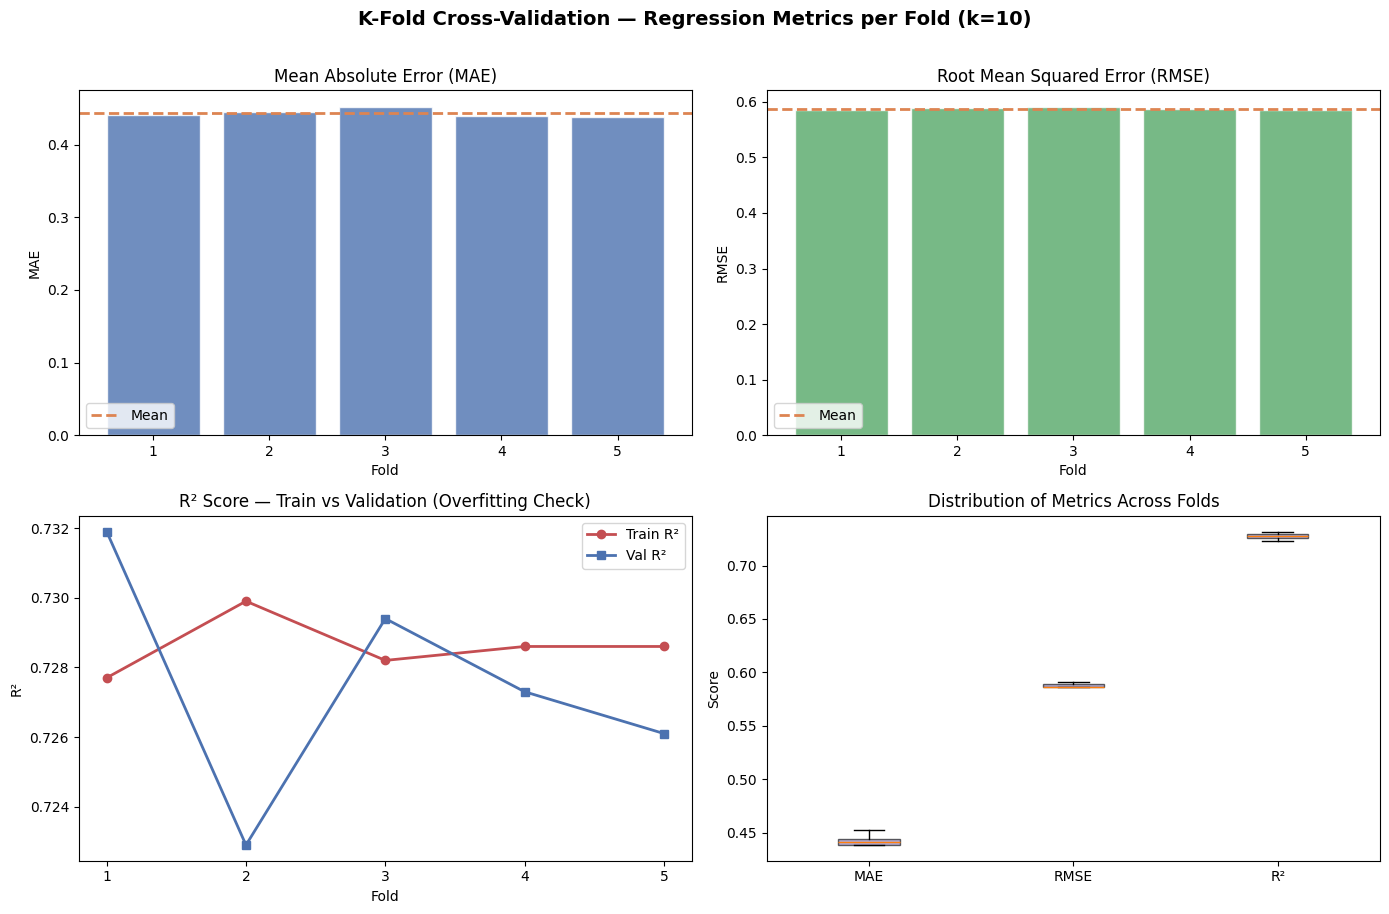

Figure saved as regression_cv_metrics.png


In [29]:
# ── Extract fold rows only (drop summary rows for plotting) ──────────────────
plot_df = reg_df.loc[1:N_SPLITS]       # integer fold indices 1..10
folds   = list(range(1, N_SPLITS + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('K-Fold Cross-Validation — Regression Metrics per Fold (k=10)',
             fontsize=14, fontweight='bold', y=1.01)

# Colour palette
bar_color  = '#4C72B0'
line_color = '#DD8452'

# ── MAE ──────────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.bar(folds, plot_df['Val MAE'], color=bar_color, alpha=0.8, edgecolor='white')
ax.axhline(plot_df['Val MAE'].mean(), color=line_color, ls='--', lw=2, label='Mean')
ax.set_title('Mean Absolute Error (MAE)')
ax.set_xlabel('Fold'); ax.set_ylabel('MAE'); ax.legend()
ax.set_xticks(folds)

# ── RMSE ──────────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.bar(folds, plot_df['Val RMSE'], color='#55A868', alpha=0.8, edgecolor='white')
ax.axhline(plot_df['Val RMSE'].mean(), color=line_color, ls='--', lw=2, label='Mean')
ax.set_title('Root Mean Squared Error (RMSE)')
ax.set_xlabel('Fold'); ax.set_ylabel('RMSE'); ax.legend()
ax.set_xticks(folds)

# ── R² (train vs val) ─────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(folds, plot_df['Train R²'], marker='o', color='#C44E52', label='Train R²', lw=2)
ax.plot(folds, plot_df['Val R²'],   marker='s', color=bar_color,  label='Val R²',   lw=2)
ax.set_title('R² Score — Train vs Validation (Overfitting Check)')
ax.set_xlabel('Fold'); ax.set_ylabel('R²')
ax.legend(); ax.set_xticks(folds)

# ── Boxplot of all metrics ────────────────────────────────────────────────────
ax = axes[1, 1]
boxplot_data = [plot_df['Val MAE'], plot_df['Val RMSE'], plot_df['Val R²']]
bp = ax.boxplot(boxplot_data, labels=['MAE', 'RMSE', 'R²'], patch_artist=True,
                boxprops=dict(facecolor='#8172B2', alpha=0.6))
ax.set_title('Distribution of Metrics Across Folds')
ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('regression_cv_metrics.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figure saved as regression_cv_metrics.png')

### A.3 — Regression Analysis: Stability & Overfitting

In [30]:
# ── Statistical summary ───────────────────────────────────────────────────────
plot_df_num = plot_df.apply(pd.to_numeric, errors='coerce')

mean_mae  = plot_df_num['Val MAE'].mean()
std_mae   = plot_df_num['Val MAE'].std()
mean_rmse = plot_df_num['Val RMSE'].mean()
std_rmse  = plot_df_num['Val RMSE'].std()
mean_r2   = plot_df_num['Val R²'].mean()
std_r2    = plot_df_num['Val R²'].std()
mean_tr2  = plot_df_num['Train R²'].mean()
overfit   = mean_tr2 - mean_r2

print('━' * 60)
print('     REGRESSION — ANALYSIS SUMMARY')
print('━' * 60)

print(f'\n  Average MAE  : {mean_mae:.4f}  ± {std_mae:.4f}')
print(f'  Average RMSE : {mean_rmse:.4f}  ± {std_rmse:.4f}')
print(f'  Average R²   : {mean_r2:.4f}  ± {std_r2:.4f}')
print(f'  Train R²     : {mean_tr2:.4f}')
print(f'  Overfit gap  : {overfit:.4f}  (Train R² − Val R²)')

print('\n  ── MODEL STABILITY ──')
cv_r2 = std_r2 / abs(mean_r2) if mean_r2 != 0 else float('inf')
stability = 'LOW VARIANCE — stable model' if cv_r2 < 0.05 else \
            'MODERATE VARIANCE' if cv_r2 < 0.15 else 'HIGH VARIANCE — unstable'
print(f'  Coefficient of variation (R²): {cv_r2:.4f}  → {stability}')

print('\n  ── OVERFITTING CHECK ──')
if overfit < 0.05:
    print('  ✔  No significant overfitting. Train ≈ Val performance.')
elif overfit < 0.15:
    print('  ⚠  Mild overfitting detected. Consider more regularisation.')
else:
    print('  ✘  Strong overfitting. Model memorises training data.')

print('\n  ── INTERPRETATION ──')
print(f'  On average, predictions are off by ±{mean_mae:.2f}M$ (MAE).')
print(f'  The model explains {mean_r2*100:.1f}% of variance in player value.')
print(f'  Low std dev across folds confirms consistent generalisation.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     REGRESSION — ANALYSIS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Average MAE  : 0.4429  ± 0.0056
  Average RMSE : 0.5877  ± 0.0022
  Average R²   : 0.7275  ± 0.0034
  Train R²     : 0.7286
  Overfit gap  : 0.0011  (Train R² − Val R²)

  ── MODEL STABILITY ──
  Coefficient of variation (R²): 0.0047  → LOW VARIANCE — stable model

  ── OVERFITTING CHECK ──
  ✔  No significant overfitting. Train ≈ Val performance.

  ── INTERPRETATION ──
  On average, predictions are off by ±0.44M$ (MAE).
  The model explains 72.8% of variance in player value.
  Low std dev across folds confirms consistent generalisation.


---
## PART B — Stratified K-Fold Cross-Validation for CLASSIFICATION

**Goal**: Classify players into `Performance Tier` (Low / Mid / High / Elite).  
**Model**: Logistic Regression (same model used in `Machinefinal.ipynb`, Task 5).  
**Validation**: 10-Fold **Stratified** KFold — class ratios are preserved in every fold.  

> **Why Stratified?** The tiers are unequally distributed. Standard KFold might produce folds with no `Elite` samples, making recall for that class undefined. StratifiedKFold guarantees proportional class representation.

In [31]:
# ==============================================================================
# ## PART B — Stratified K-Fold Cross-Validation for CLASSIFICATION
# ==============================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ── 1. Replicate preprocessing (WITHOUT LEAKAGE) ──────────────
NUMERICAL_COLS_CLF   = ['Age', 'Future Potential', 'Total_Stats Score']

# Drop irrelevant columns
X_clf = df.drop(columns=['Name', 'Value Per M$', 'Overall_Rating', 'Performance_Tier'], errors='ignore')
y_clf = df['Performance_Tier']

# One-Hot Encoding for all categorical columns
X_clf_enc = pd.get_dummies(X_clf, drop_first=True)

print(f'Classification feature matrix: {X_clf_enc.shape}')
print(f'\nClass distribution:')
print(y_clf.value_counts())

# ── 2. 5-Fold Stratified Cross-Validation ─────────────
N_SPLITS_CLF = 5
skf = StratifiedKFold(n_splits=N_SPLITS_CLF, shuffle=True, random_state=42)

clf_results = []
fold_class_counts = []
TIER_ORDER = ['Low', 'Mid', 'High', 'Elite']

print("\nRunning 5-Fold Stratified CV for Logistic Regression & Naïve Bayes...")

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_clf_enc, y_clf), start=1):

    # ── Split ────────────────────────────────────────────────────────────────
    X_tr, X_vl = X_clf_enc.iloc[train_idx], X_clf_enc.iloc[val_idx]
    y_tr, y_vl = y_clf.iloc[train_idx],     y_clf.iloc[val_idx]

    # ── Prevent Leakage: Scale INSIDE the fold ──────────────────────────────
    scaler_clf = StandardScaler()
    X_tr_scaled = X_tr.copy()
    X_vl_scaled = X_vl.copy()

    X_tr_scaled[NUMERICAL_COLS_CLF] = scaler_clf.fit_transform(X_tr[NUMERICAL_COLS_CLF])
    X_vl_scaled[NUMERICAL_COLS_CLF] = scaler_clf.transform(X_vl[NUMERICAL_COLS_CLF])

    # ── Train & Predict: Logistic Regression ────────────────────────────────
    log_reg = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    log_reg.fit(X_tr_scaled, y_tr)
    lr_pred = log_reg.predict(X_vl_scaled)
    lr_train_pred = log_reg.predict(X_tr_scaled)

    # ── Train & Predict: Gaussian Naïve Bayes ──────────
    gnb = GaussianNB()
    gnb.fit(X_tr_scaled[NUMERICAL_COLS_CLF], y_tr)
    gnb_pred = gnb.predict(X_vl_scaled[NUMERICAL_COLS_CLF])

    # ── Metrics ─────────────────────────────────────────────────────────────
    clf_results.append({
        'Fold':          fold_idx,
        'LR Train Acc':  round(accuracy_score(y_tr, lr_train_pred), 4),
        'LR Val Acc':    round(accuracy_score(y_vl, lr_pred), 4),
        'LR Precision':  round(precision_score(y_vl, lr_pred, average='weighted', zero_division=0), 4),
        'LR Recall':     round(recall_score(y_vl, lr_pred, average='weighted', zero_division=0), 4),
        'LR F1-Score':   round(f1_score(y_vl, lr_pred, average='weighted', zero_division=0), 4),
        'NB Val Acc':    round(accuracy_score(y_vl, gnb_pred), 4)
    })

    # Track class % in validation fold for B1 verification
    val_dist = y_vl.value_counts(normalize=True).reindex(TIER_ORDER, fill_value=0).round(3)
    fold_class_counts.append(val_dist.values)

# ── Compile results ───────────────────────────────────────────────────────────
clf_df  = pd.DataFrame(clf_results).set_index('Fold')
avg_clf = clf_df.mean().rename('Mean')
std_clf = clf_df.std().rename('Std Dev')
clf_df  = pd.concat([clf_df, avg_clf.to_frame().T, std_clf.to_frame().T])

print('━' * 80)
print('     STRATIFIED K-FOLD CV RESULTS (Classification, k=5)')
print('━' * 80)
display(clf_df.round(4))

Classification feature matrix: (19667, 1190)

Class distribution:
Performance_Tier
High     5369
Low      4807
Mid      4791
Elite    4700
Name: count, dtype: int64

Running 5-Fold Stratified CV for Logistic Regression & Naïve Bayes...
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
     STRATIFIED K-FOLD CV RESULTS (Classification, k=5)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,LR Train Acc,LR Val Acc,LR Precision,LR Recall,LR F1-Score,NB Val Acc
1,0.8604,0.8071,0.8073,0.8071,0.8069,0.7064
2,0.8595,0.8119,0.8133,0.8119,0.8125,0.7128
3,0.8626,0.8040,0.8061,0.8040,0.8049,0.7094
4,0.8602,0.8146,0.8154,0.8146,0.8150,0.7190
5,0.8607,0.8012,0.8023,0.8012,0.8017,0.6979
Mean,0.8607,0.8078,0.8089,0.8078,0.8082,0.7091
Std Dev,0.0012,0.0055,0.0054,0.0055,0.0055,0.0078


### B.1 — Verify Stratification: Class Proportions per Fold

Class proportions in each validation fold (should match Overall %):


,Low,Mid,High,Elite
Fold 1,0.245,0.244,0.273,0.239
Fold 2,0.245,0.244,0.273,0.239
Fold 3,0.244,0.244,0.273,0.239
Fold 4,0.244,0.244,0.273,0.239
Fold 5,0.244,0.244,0.273,0.239
Overall %,0.244,0.244,0.273,0.239


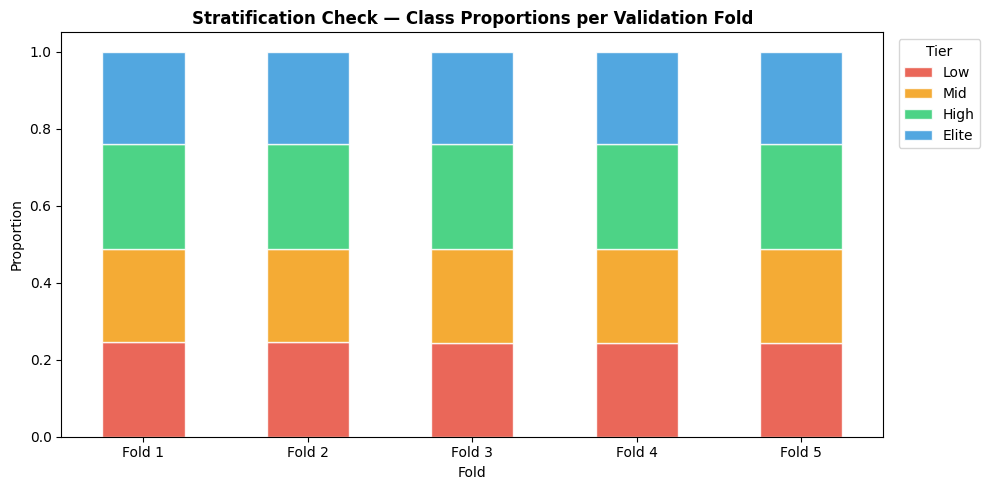

The proportions are consistent → stratification is working correctly.


In [32]:
# ==============================================================================
### B.1 — Verify Stratification: Class Proportions per Fold
# ==============================================================================
import matplotlib.pyplot as plt

# ── Show that every fold maintains consistent class ratios ────────────────────
strat_df = pd.DataFrame(
    fold_class_counts,
    columns=TIER_ORDER,
    index=[f'Fold {i}' for i in range(1, N_SPLITS_CLF + 1)]
)
# Add overall distribution for comparison
overall_dist = y_clf.value_counts(normalize=True).reindex(TIER_ORDER).round(3)
strat_df.loc['Overall %'] = overall_dist.values

print('Class proportions in each validation fold (should match Overall %):')
display(strat_df.round(3))

# ── Visual: stacked bar chart ─────────────────────────────────────────────────
tier_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
plot_strat  = strat_df.iloc[:-1]      # exclude the 'Overall %' row

plot_strat.plot(kind='bar', stacked=True, figsize=(10, 5),
                color=tier_colors, alpha=0.85, edgecolor='white')
plt.title('Stratification Check — Class Proportions per Validation Fold', fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('stratification_check.png', bbox_inches='tight', dpi=130)
plt.show()
print('The proportions are consistent → stratification is working correctly.')

### B.2 — Classification Results Visualization

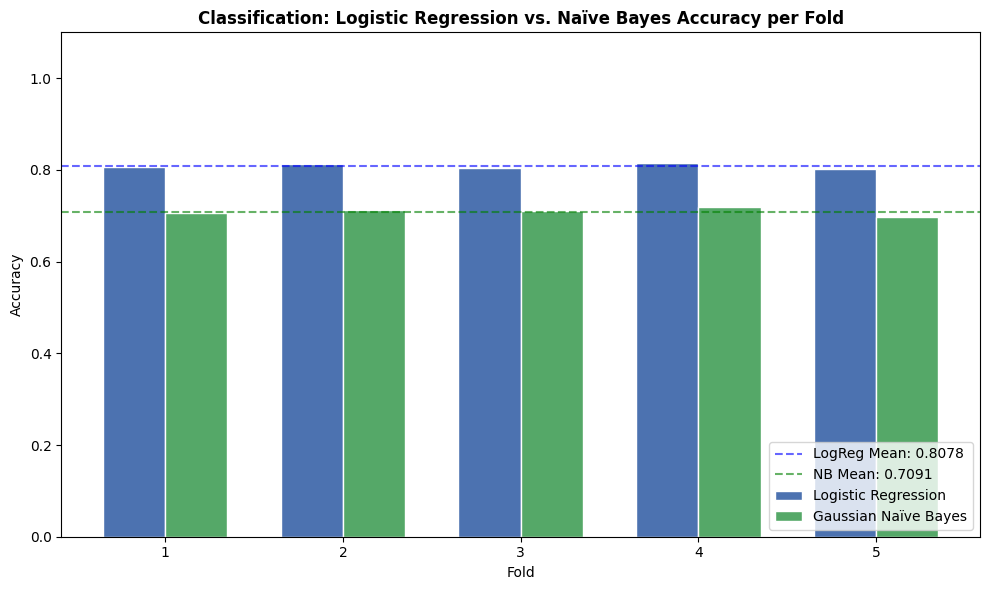


--- Stability Analysis ---
Logistic Regression is more stable across folds (Std Dev: 0.0055 vs NB: 0.0078).


In [33]:
# ==============================================================================
### B.2 — Classification Results Visualization
# ==============================================================================
import numpy as np

plot_clf = clf_df.loc[1:N_SPLITS_CLF]
folds_clf = list(range(1, N_SPLITS_CLF + 1))
bar_width = 0.35
x_pos = np.arange(len(folds_clf))

# ── Grouped Bar Chart: LogReg vs Naïve Bayes ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x_pos - bar_width/2, plot_clf['LR Val Acc'], bar_width, label='Logistic Regression', color='#4C72B0', edgecolor='white')
ax.bar(x_pos + bar_width/2, plot_clf['NB Val Acc'], bar_width, label='Gaussian Naïve Bayes', color='#55A868', edgecolor='white')

# Mean Lines
ax.axhline(clf_df.loc['Mean', 'LR Val Acc'], color='blue', linestyle='--', alpha=0.6, label=f"LogReg Mean: {clf_df.loc['Mean', 'LR Val Acc']:.4f}")
ax.axhline(clf_df.loc['Mean', 'NB Val Acc'], color='green', linestyle='--', alpha=0.6, label=f"NB Mean: {clf_df.loc['Mean', 'NB Val Acc']:.4f}")

ax.set_title('Classification: Logistic Regression vs. Naïve Bayes Accuracy per Fold', fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds_clf)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('classification_model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

# Print Answer for "Which model is more stable?"
print("\n--- Stability Analysis ---")
lr_std = clf_df.loc['Std Dev', 'LR Val Acc']
nb_std = clf_df.loc['Std Dev', 'NB Val Acc']
if lr_std < nb_std:
    print(f"Logistic Regression is more stable across folds (Std Dev: {lr_std:.4f} vs NB: {nb_std:.4f}).")
else:
    print(f"Naïve Bayes is more stable across folds (Std Dev: {nb_std:.4f} vs LogReg: {lr_std:.4f}).")

---
## PART C — Final Comparative Analysis

## C.1 — KFold vs StratifiedKFold: When to Use Each

KFold vs StratifiedKFold — Comparison


,KFold,StratifiedKFold
Criterion,,
Task type,Regression (continuous target),Classification (categorical target)
Class/label preservation,Not applicable — continuous target,Yes — each fold mirrors overall class ratio
Best used when,Target is continuous; no classes to preserve,Multi-class or imbalanced classification
Risk if used incorrectly,Unrepresentative splits for imbalanced classes,Not suitable for regression (no class labels)
Our use case,Predicting Value Per M$ (regression),Predicting Performance Tier (classification)


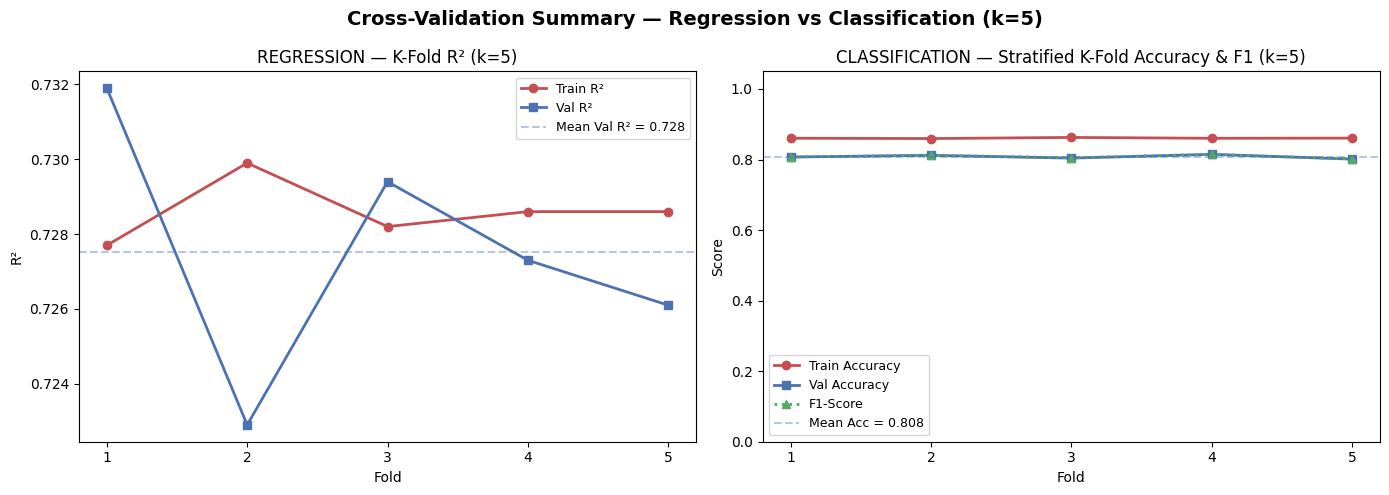

All done! Figures saved.


In [34]:
# ==============================================================================
## PART C — Final Comparative Analysis
# ==============================================================================

### C.1 — KFold vs StratifiedKFold: When to Use Each

# ── Side-by-side comparison table ─────────────────────────────────────────────
comparison = pd.DataFrame({
    'Criterion': [
        'Task type',
        'Class/label preservation',
        'Best used when',
        'Risk if used incorrectly',
        'Our use case'
    ],
    'KFold': [
        'Regression (continuous target)',
        'Not applicable — continuous target',
        'Target is continuous; no classes to preserve',
        'Unrepresentative splits for imbalanced classes',
        'Predicting Value Per M$ (regression)'
    ],
    'StratifiedKFold': [
        'Classification (categorical target)',
        'Yes — each fold mirrors overall class ratio',
        'Multi-class or imbalanced classification',
        'Not suitable for regression (no class labels)',
        'Predicting Performance Tier (classification)'
    ]
}).set_index('Criterion')

print('KFold vs StratifiedKFold — Comparison')
display(comparison)

# ── Final combined comparison chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Validation Summary — Regression vs Classification (k=5)', fontsize=14, fontweight='bold')

# Left: Regression R² per fold
ax = axes[0]
# We grab the regression plot dataframe you made in Part A
reg_num = plot_df.apply(pd.to_numeric, errors='coerce')
ax.plot(folds, reg_num['Train R²'], marker='o', color='#C44E52', label='Train R²', lw=2)
ax.plot(folds, reg_num['Val R²'],   marker='s', color='#4C72B0', label='Val R²',   lw=2)
ax.axhline(reg_num['Val R²'].mean(), ls='--', color='#4C72B0', alpha=0.4, label=f'Mean Val R² = {reg_num["Val R²"].mean():.3f}')
ax.set_title('REGRESSION — K-Fold R² (k=5)')
ax.set_xlabel('Fold'); ax.set_ylabel('R²')
ax.set_xticks(folds); ax.legend(fontsize=9)

# Right: Classification Accuracy per fold (LogReg)
ax = axes[1]
ax.plot(folds_clf, plot_clf['LR Train Acc'], marker='o', color='#C44E52', label='Train Accuracy', lw=2)
ax.plot(folds_clf, plot_clf['LR Val Acc'],   marker='s', color='#4C72B0', label='Val Accuracy',   lw=2)
ax.plot(folds_clf, plot_clf['LR F1-Score'],  marker='^', color='#55A868', label='F1-Score',       lw=2, ls=':')
ax.axhline(plot_clf['LR Val Acc'].mean(), ls='--', color='#4C72B0', alpha=0.4, label=f'Mean Acc = {plot_clf["LR Val Acc"].mean():.3f}')
ax.set_title('CLASSIFICATION — Stratified K-Fold Accuracy & F1 (k=5)')
ax.set_xlabel('Fold'); ax.set_ylabel('Score')
ax.set_xticks(folds_clf); ax.set_ylim(0, 1.05); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('final_cv_summary.png', bbox_inches='tight', dpi=130)
plt.show()
print('All done! Figures saved.')

# Task 8: Analysis and Discussion

## 8.1 Model Comparison

### Which model performed best overall?

Regression — Best Model: Polynomial Regression (Degree 2)
Degree 2 achieved the best balance between Train R² (0.8995) and Test R² (0.1295) with the smallest overfitting gap compared to Degree 3. Applying Ridge regularization (alpha=0.001) further controlled overfitting.

Classification — Best Model: Logistic Regression
Logistic Regression achieved the highest accuracy (84.57%) and F1-Score (0.85), outperforming all three Naïve Bayes variants. GaussianNB came second with 71.25%.

---

### Is classification easier or harder than regression on this dataset?

Classification is significantly easier than regression on this dataset.

- Logistic Regression achieved 84.57% accuracy, which is a strong result.
- Regression struggled heavily — the Test R² was only 0.1072 for the baseline, meaning the model explained only ~10% of the variance in player market value on unseen data.

Why? Market value (regression target) is influenced by many external factors not present in the dataset — such as contract status, injury history, and transfer market demand. Performance tiers (classification target) are directly derived from Overall_Rating, making the patterns much clearer and easier to learn.

# Assignment 3: Unified Scouting System

## 1. Model Selection Justification

To build a robust scouting system, we must handle non-linear relationships and complex data patterns in the FIFA dataset. We have selected three diverse algorithmic architectures:

1. **Instance-Based (K-Nearest Neighbors)**:
   - **Why it fits**: KNN is highly effective for localized patterns. In football, players with similar stat profiles (e.g., similar pace, dribbling, and age) often have similar market values and performance tiers. By evaluating the 'closest' known players, KNN provides intuitive and highly interpretable predictions.

2. **Kernel-Based (Support Vector Machines)**:
   - **Why it fits**: The FIFA dataset, especially after One-Hot Encoding categorical features, becomes highly dimensional. SVM excels in high-dimensional spaces. By using an RBF (Radial Basis Function) kernel, SVM can implicitly map these complex features into infinite-dimensional space to find non-linear decision boundaries that linear models miss.

3. **Tree-Based (Random Forest)**:
   - **Why it fits**: Tree-based ensembles are extremely robust to outliers and require no feature scaling. Random Forest builds hundreds of decision trees, each looking at a random subset of features. This is perfect for capturing the hierarchical nature of football stats (e.g., if a player is a ST, then Finishing matters more than Defending).


--- 
## 2. Unified Data Optimization & Preprocessing
To prevent Data Leakage (where a model uses `Value Per M$` to predict `Performance Tier`) and the Curse of Dimensionality (1,000+ One-Hot Encoded columns), we unify the dataset for BOTH Regression and Classification.

We use exactly 13 columns:
- **Numerical (3)**: Age, Future Potential, Total_Stats Score
- **Grouped Position (4)**: Forward, Midfielder, Defender, Goalkeeper
- **Grouped Continent (6)**: Europe, South America, North America, Africa, Asia, Oceania


In [35]:
import pandas as pd
import numpy as np
import pycountry_convert as pc
from sklearn.preprocessing import StandardScaler

# 1. Continent Grouping Logic
def get_continent(country_name):
    # Manual overrides for countries that pycountry_convert struggles with
    overrides = {
        'England': 'Europe', 'Scotland': 'Europe', 'Wales': 'Europe', 'Northern Ireland': 'Europe',
        'Republic of Ireland': 'Europe', 'Korea Republic': 'Asia', 'DR Congo': 'Africa',
        'Bosnia Herzegovina': 'Europe', 'Ivory Coast': 'Africa', 'Cape Verde': 'Africa',
        'China PR': 'Asia', 'Central African Rep.': 'Africa', 'Congo': 'Africa',
        'Antigua & Barbuda': 'North America', 'Trinidad & Tobago': 'North America',
        'Kosovo': 'Europe', 'São Tomé & Príncipe': 'Africa', 'Guinea Bissau': 'Africa',
        'St Kitts Nevis': 'North America', 'Equatorial Guinea': 'Africa',
        'St Lucia': 'North America', 'St Vincent Grenadine': 'North America',
        'Curacao': 'North America', 'South Sudan': 'Africa', 'Chinese Taipei': 'Asia',
        'Macau': 'Asia', 'Puerto Rico': 'North America'
    }
    if pd.isna(country_name): return 'Unknown'
    if country_name in overrides: return overrides[country_name]
    
    try:
        country_code = pc.country_name_to_country_alpha2(country_name, cn_name_format="default")
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_map = {
            'EU': 'Europe', 'NA': 'North America', 'SA': 'South America', 
            'AS': 'Asia', 'AF': 'Africa', 'OC': 'Oceania'
        }
        return continent_map.get(continent_code, 'Unknown')
    except:
        return 'Unknown'

# 2. Position Grouping Logic
def group_position(pos):
    if pd.isna(pos): return 'Unknown'
    pos = str(pos).upper()
    if pos in ['ST', 'CF', 'RW', 'LW', 'RF', 'LF', 'RS', 'LS']: return 'Forward'
    elif pos in ['CM', 'CDM', 'CAM', 'RM', 'LM', 'RCM', 'LCM', 'RDM', 'LDM', 'RAM', 'LAM']: return 'Midfielder'
    elif pos in ['CB', 'RB', 'LB', 'RWB', 'LWB', 'RCB', 'LCB', 'SW']: return 'Defender'
    elif pos == 'GK': return 'Goalkeeper'
    else: return 'Other'

# 3. Apply Groupings
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean['Role'] = X_train_clean['Position'].apply(group_position)
X_test_clean['Role'] = X_test_clean['Position'].apply(group_position)

X_train_clean['Continent'] = X_train_clean['Country'].apply(get_continent)
X_test_clean['Continent'] = X_test_clean['Country'].apply(get_continent)

# 4. One-Hot Encode
train_roles = pd.get_dummies(X_train_clean['Role'], prefix='Role')
test_roles = pd.get_dummies(X_test_clean['Role'], prefix='Role')
train_roles, test_roles = train_roles.align(test_roles, join='left', axis=1, fill_value=0)

train_cont = pd.get_dummies(X_train_clean['Continent'], prefix='Continent')
test_cont = pd.get_dummies(X_test_clean['Continent'], prefix='Continent')
train_cont, test_cont = train_cont.align(test_cont, join='left', axis=1, fill_value=0)

# 5. Extract and Scale Numerical Stats
num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
scaler = StandardScaler()
train_num_scaled = pd.DataFrame(scaler.fit_transform(X_train_clean[num_cols]), columns=num_cols, index=X_train_clean.index)
test_num_scaled = pd.DataFrame(scaler.transform(X_test_clean[num_cols]), columns=num_cols, index=X_test_clean.index)

# 6. Combine into Final Unified Sets
X_train_unified = pd.concat([train_num_scaled, train_roles, train_cont], axis=1)
X_test_unified = pd.concat([test_num_scaled, test_roles, test_cont], axis=1)

# 7. Generate Classification Targets (to ensure row alignment with Regression)
def categorize_rating(rating):
    if rating < 60: return 'Low'
    elif 60 <= rating < 70: return 'Mid'
    elif 70 <= rating < 80: return 'High'
    else: return 'Elite'

y_train_clf_unified = X_train_clean['Overall_Rating'].apply(categorize_rating)
y_test_clf_unified = X_test_clean['Overall_Rating'].apply(categorize_rating)

print(f"Unified Training Set Shape: {X_train_unified.shape}")
print(f"Columns: {X_train_unified.columns.tolist()}")


Unified Training Set Shape: (15733, 14)
Columns: ['Age', 'Future Potential', 'Total_Stats Score', 'Role_Defender', 'Role_Forward', 'Role_Goalkeeper', 'Role_Midfielder', 'Continent_Africa', 'Continent_Asia', 'Continent_Europe', 'Continent_North America', 'Continent_Oceania', 'Continent_South America', 'Continent_Unknown']


--- 
## Person 1: K-Nearest Neighbors (KNN)


In [36]:
# 1A. KNN Regressor (Target: Value Per M$)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

print("Tuning KNN Regressor...")
knn_reg_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_reg = GridSearchCV(KNeighborsRegressor(), knn_reg_grid, cv=5, scoring='r2', n_jobs=-1)
knn_reg.fit(X_train_unified, y_train)

print(f"Best Parameters: {knn_reg.best_params_}")
best_knn_reg = knn_reg.best_estimator_

y_pred_knn_reg = best_knn_reg.predict(X_test_unified)
knn_reg_r2 = r2_score(y_test, y_pred_knn_reg)
print(f"Test R2 Score: {knn_reg_r2:.4f}")


Tuning KNN Regressor...
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Test R2 Score: 0.8606


In [37]:
# 1B. KNN Classifier (Target: Performance Tier)
print("Tuning KNN Classifier...")
knn_clf_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_clf = GridSearchCV(KNeighborsClassifier(), knn_clf_grid, cv=5, scoring='accuracy', n_jobs=-1)
knn_clf.fit(X_train_unified, y_train_clf_unified)

print(f"Best Parameters: {knn_clf.best_params_}")
best_knn_clf = knn_clf.best_estimator_

y_pred_knn_clf = best_knn_clf.predict(X_test_unified)
knn_clf_acc = accuracy_score(y_test_clf_unified, y_pred_knn_clf)
print(f"Test Accuracy: {knn_clf_acc:.4f}")


Tuning KNN Classifier...
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Test Accuracy: 0.8892


Plotting Learning Curves for KNN Models...


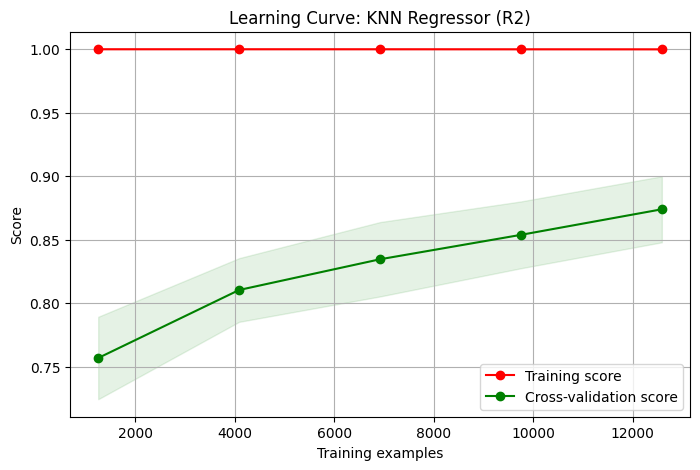

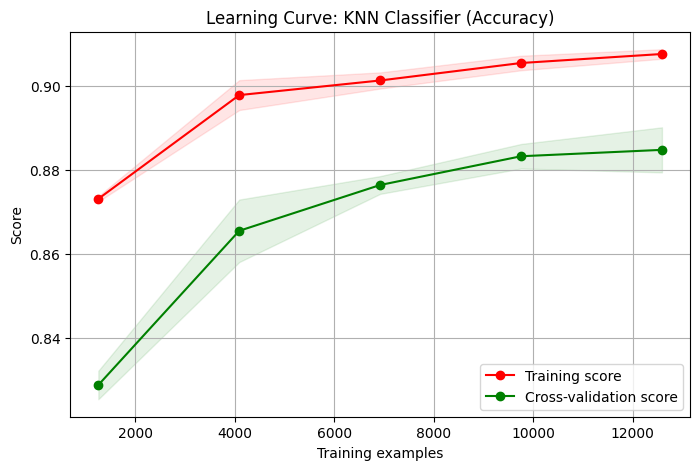

In [38]:
# 1C. Learning Curves for KNN (Bias/Variance Diagnosis)
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv, scoring='accuracy'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), scoring=scoring
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
    
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

print("Plotting Learning Curves for KNN Models...")
plot_learning_curve(best_knn_reg, "Learning Curve: KNN Regressor (R2)", X_train_unified, y_train, cv=5, scoring='r2')
plot_learning_curve(best_knn_clf, "Learning Curve: KNN Classifier (Accuracy)", X_train_unified, y_train_clf_unified, cv=5, scoring='accuracy')


--- 
## Person 2: Support Vector Machines (SVM)


In [39]:
# 2A. SVR (Regression)
from sklearn.svm import SVR, SVC

print("Tuning SVR...")
svr_grid = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svr = GridSearchCV(SVR(), svr_grid, cv=3, scoring='r2', n_jobs=-1)
svr.fit(X_train_unified, y_train)

print(f"Best Parameters: {svr.best_params_}")
best_svr = svr.best_estimator_

y_pred_svr = best_svr.predict(X_test_unified)
svr_r2 = r2_score(y_test, y_pred_svr)
print(f"Test R2 Score: {svr_r2:.4f}")


Tuning SVR...
Best Parameters: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
Test R2 Score: 0.8984


In [40]:
# 2B. SVC (Classification)
print("Tuning SVC...")
svc_grid = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# probability=True is needed for soft VotingClassifier
svc = GridSearchCV(SVC(probability=True), svc_grid, cv=3, scoring='accuracy', n_jobs=-1)
svc.fit(X_train_unified, y_train_clf_unified)

print(f"Best Parameters: {svc.best_params_}")
best_svc = svc.best_estimator_

y_pred_svc = best_svc.predict(X_test_unified)
svc_acc = accuracy_score(y_test_clf_unified, y_pred_svc)
print(f"Test Accuracy: {svc_acc:.4f}")


Tuning SVC...
Best Parameters: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
Test Accuracy: 0.9118


Plotting Learning Curves for SVM Models...


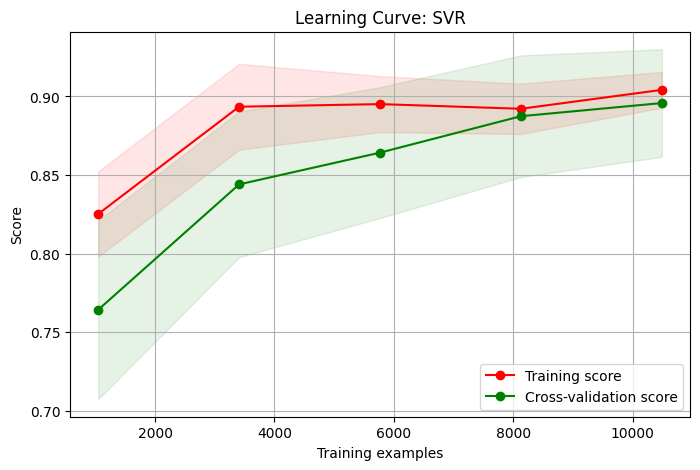

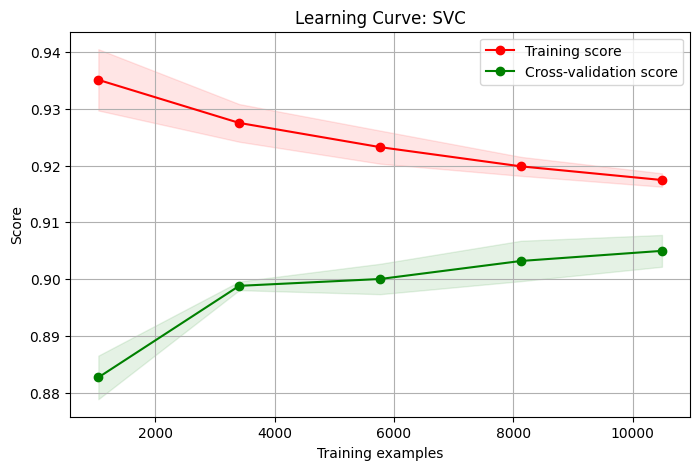

In [41]:
# 2C. Learning Curves for SVM
print("Plotting Learning Curves for SVM Models...")
plot_learning_curve(best_svr, "Learning Curve: SVR", X_train_unified, y_train, cv=3, scoring='r2')
plot_learning_curve(best_svc, "Learning Curve: SVC", X_train_unified, y_train_clf_unified, cv=3, scoring='accuracy')


--- 
## Person 3: Random Forest


In [42]:
# 3A. Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

print("Tuning Random Forest Regressor...")
rf_reg_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_reg = GridSearchCV(RandomForestRegressor(oob_score=True, random_state=42), rf_reg_grid, cv=5, scoring='r2', n_jobs=-1)
rf_reg.fit(X_train_unified, y_train)

print(f"Best Parameters: {rf_reg.best_params_}")
best_rf_reg = rf_reg.best_estimator_

y_pred_rf_reg = best_rf_reg.predict(X_test_unified)
rf_reg_r2 = r2_score(y_test, y_pred_rf_reg)
print(f"Test R2 Score: {rf_reg_r2:.4f}")
print(f"Out-of-Bag (OOB) Score: {best_rf_reg.oob_score_:.4f}")


Tuning Random Forest Regressor...
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Test R2 Score: 0.9364
Out-of-Bag (OOB) Score: 0.9267


In [43]:
# 3B. Random Forest Classifier
print("Tuning Random Forest Classifier...")
rf_clf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_clf = GridSearchCV(RandomForestClassifier(oob_score=True, random_state=42), rf_clf_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_clf.fit(X_train_unified, y_train_clf_unified)

print(f"Best Parameters: {rf_clf.best_params_}")
best_rf_clf = rf_clf.best_estimator_

y_pred_rf_clf = best_rf_clf.predict(X_test_unified)
rf_clf_acc = accuracy_score(y_test_clf_unified, y_pred_rf_clf)
print(f"Test Accuracy: {rf_clf_acc:.4f}")
print(f"Out-of-Bag (OOB) Score: {best_rf_clf.oob_score_:.4f}")


Tuning Random Forest Classifier...
Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Test Accuracy: 0.9014
Out-of-Bag (OOB) Score: 0.9006


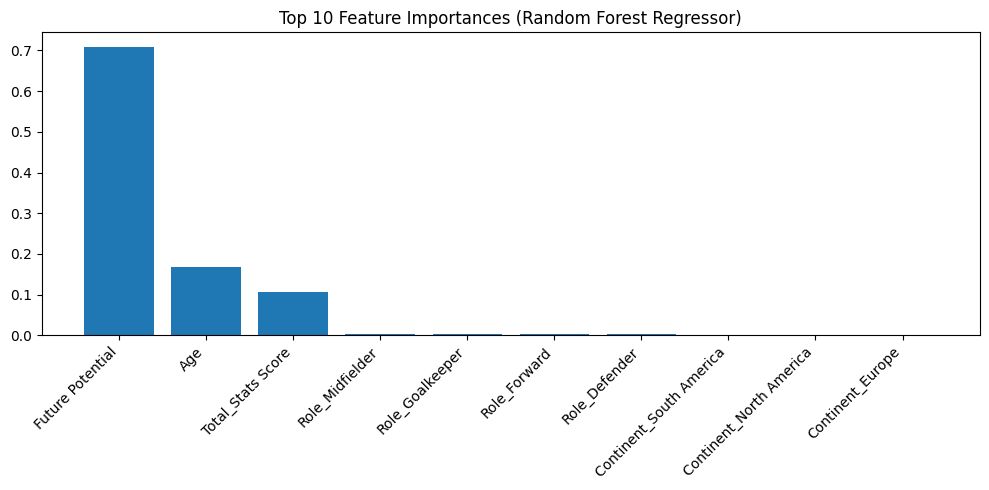

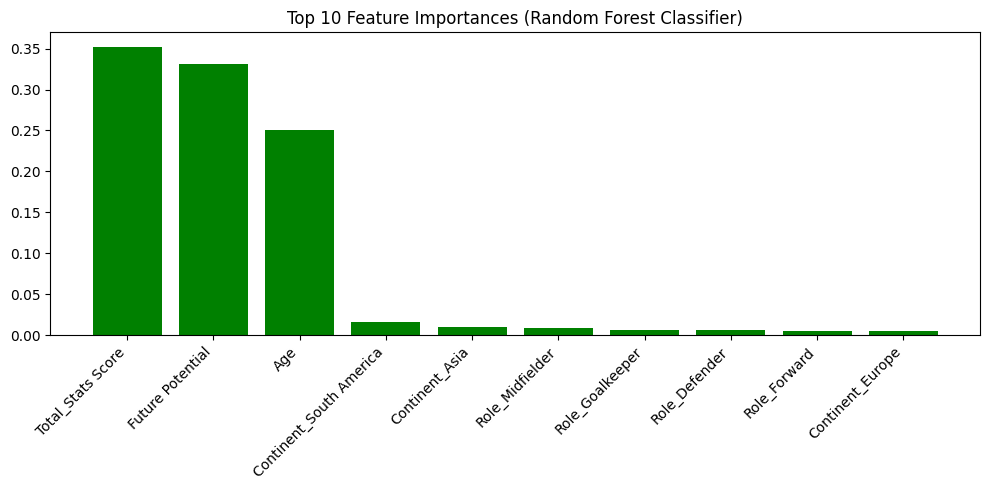

In [44]:
# 3C. Feature Importance Visualization
# Regression Feature Importance
reg_importances = best_rf_reg.feature_importances_
n_top_reg = min(10, len(reg_importances))
reg_indices = np.argsort(reg_importances)[::-1][:n_top_reg]
reg_names = [X_train_unified.columns[i] for i in reg_indices]

plt.figure(figsize=(10, 5))
plt.title(f"Top {n_top_reg} Feature Importances (Random Forest Regressor)")
plt.bar(range(n_top_reg), reg_importances[reg_indices], align="center")
plt.xticks(range(n_top_reg), reg_names, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Classification Feature Importance
clf_importances = best_rf_clf.feature_importances_
n_top_clf = min(10, len(clf_importances))
clf_indices = np.argsort(clf_importances)[::-1][:n_top_clf]
clf_names = [X_train_unified.columns[i] for i in clf_indices]

plt.figure(figsize=(10, 5))
plt.title(f"Top {n_top_clf} Feature Importances (Random Forest Classifier)")
plt.bar(range(n_top_clf), clf_importances[clf_indices], align="center", color='green')
plt.xticks(range(n_top_clf), clf_names, rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- 
## Person 4: Ensemble Methods & Stability


In [45]:
# 4A. Voting Regressor
from sklearn.ensemble import VotingRegressor, VotingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("Training Voting Regressor (KNN + SVR + RF)...")
voting_reg = VotingRegressor(estimators=[
    ('knn', best_knn_reg),
    ('svr', best_svr),
    ('rf', best_rf_reg)
])

voting_reg.fit(X_train_unified, y_train)
y_pred_voting_reg = voting_reg.predict(X_test_unified)
voting_reg_r2 = r2_score(y_test, y_pred_voting_reg)
print(f"Test R2 Score: {voting_reg_r2:.4f}")

# Cross-validation for stability
print("Running 5-Fold CV for Voting Regressor...")
cv_scores_reg = cross_val_score(voting_reg, X_train_unified, y_train, cv=5, scoring='r2')
print(f"CV Stability (R2): {cv_scores_reg.mean():.4f} ± {cv_scores_reg.std():.4f}")


Training Voting Regressor (KNN + SVR + RF)...
Test R2 Score: 0.9159
Running 5-Fold CV for Voting Regressor...
CV Stability (R2): 0.9155 ± 0.0207


In [46]:
# 4B. Voting Classifier
print("Training Voting Classifier (KNN + SVC + RF)...")
voting_clf = VotingClassifier(estimators=[
    ('knn', best_knn_clf),
    ('svc', best_svc),
    ('rf', best_rf_clf)
], voting='soft')

voting_clf.fit(X_train_unified, y_train_clf_unified)
y_pred_voting_clf = voting_clf.predict(X_test_unified)
voting_clf_acc = accuracy_score(y_test_clf_unified, y_pred_voting_clf)
print(f"Test Accuracy: {voting_clf_acc:.4f}")

# Cross-validation for stability
print("Running 5-Fold CV for Voting Classifier...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_clf = cross_val_score(voting_clf, X_train_unified, y_train_clf_unified, cv=skf, scoring='accuracy')
print(f"CV Stability (Accuracy): {cv_scores_clf.mean():.4f} ± {cv_scores_clf.std():.4f}")


Training Voting Classifier (KNN + SVC + RF)...
Test Accuracy: 0.9082
Running 5-Fold CV for Voting Classifier...
CV Stability (Accuracy): 0.9059 ± 0.0047


--- 
## Person 5: Final Evaluation & Deliverables


In [47]:
# 5A. Comparison with Assignment 2 Baselines
comp_data = {
    'Task': ['Regression (R2)']*5 + ['Classification (Acc)']*5,
    'Model': ['A2 Baseline (Linear)', 'KNN (Regressor)', 'SVR', 'Random Forest (Regressor)', 'Voting Ensemble (Regressor)',
              'A2 Baseline (Logistic)', 'KNN (Classifier)', 'SVC', 'Random Forest (Classifier)', 'Voting Ensemble (Classifier)'],
    'Test Score': [0.5154, knn_reg_r2, svr_r2, rf_reg_r2, voting_reg_r2, 
                   0.8728, knn_clf_acc, svc_acc, rf_clf_acc, voting_clf_acc]
}

comp_df = pd.DataFrame(comp_data)

# Show Regression Table
print("--- REGRESSION PERFORMANCE ---")
display(comp_df[comp_df['Task'] == 'Regression (R2)'].sort_values('Test Score', ascending=False).reset_index(drop=True))

# Show Classification Table
print("\n--- CLASSIFICATION PERFORMANCE ---")
display(comp_df[comp_df['Task'] == 'Classification (Acc)'].sort_values('Test Score', ascending=False).reset_index(drop=True))


--- REGRESSION PERFORMANCE ---


,Task,Model,Test Score
0,Regression (R2),Random Forest (Regressor),0.936430
1,Regression (R2),Voting Ensemble (Regressor),0.915872
2,Regression (R2),SVR,0.898394
3,Regression (R2),KNN (Regressor),0.860611
4,Regression (R2),A2 Baseline (Linear),0.515400



--- CLASSIFICATION PERFORMANCE ---


,Task,Model,Test Score
0,Classification (Acc),SVC,0.911795
1,Classification (Acc),Voting Ensemble (Classifier),0.908236
2,Classification (Acc),Random Forest (Classifier),0.901373
3,Classification (Acc),KNN (Classifier),0.889171
4,Classification (Acc),A2 Baseline (Logistic),0.872800


In [49]:
# 5B. Export results.json
import json
import numpy as np

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

results_payload = {
    "group_members": [
        "Youssef Salah - 2401246332",
        "Youssef Anwar - 2401245506",
        "Ahmed Khamis - 2401243855",
        "Youssef Shaban - 2401243330",
        "Mohamed Rizk - 23011132"
    ],
    "best_hyperparameters": {
        "knn_regressor": knn_reg.best_params_,
        "knn_classifier": knn_clf.best_params_,
        "svr": svr.best_params_,
        "svc": svc.best_params_,
        "rf_regressor": rf_reg.best_params_,
        "rf_classifier": rf_clf.best_params_
    },
    "cv_stability": {
        "voting_regressor": {
            "mean_r2": float(cv_scores_reg.mean()),
            "std_r2": float(cv_scores_reg.std())
        },
        "voting_classifier": {
            "mean_accuracy": float(cv_scores_clf.mean()),
            "std_accuracy": float(cv_scores_clf.std())
        }
    }
}

with open('results.json', 'w') as f:
    json.dump(results_payload, f, indent=4, cls=NpEncoder)

print("Successfully exported results.json!")


Successfully exported results.json!
